In [ ]:
 """
So, can this be treated as full and final proof.

    def backtrack():
        if sum(current)==target:
            result.append(current.copy())
            return
        # some code

            current.append(<some element>)
            backtrack()
            current.pop()


" Frame N knows the correct value will be popped because all deeper frames are
required to restore the list to the state it had at their entry, leaving frame
N’s appended element as the last element when control returns. " can be
justified because of this.

Each frame has an append followed by a backtrack() again followed by a pop. Lets
 say the recursion terminates at the (N+k)th frame, At that stage, because of
 the base case, backtrack() is returned a null value and then the appended value
  is popped off.

So, the terminating stage i.e. the N+k th stage did not change the value of
current at all => the N+k-1 which consists of a append, backtrack() (which will
 open N+k frame but doesnt mutate current at all),and then a pop shall also not
 change the value of  current. By induction, the value of current is not changed
  at all at any inductive step.

All this is possible because the the base case at the N+k th step does not
change the value of current because it is encountered before any append or
mutating statement. Had the base case changed the value of the current, things
would have been different as current will then change at each frame.
#########################################################################

Also,

So at any node , say A, there are two options; Either to add a "p" or a "q".

(i) If you add a "p". Fine, then bactrack on the new node and you would have
produced an entire new tree structure from this . But you should "pop" it
because you now want to add a ")" as well to the original node A. So far so good.

(ii) After it pops, you come back to the original node A and now you add a "q".
you call backtrack again so that an entire new tree forms out of this. and then
you "pop" it so that you come back to the original node A

What happens next?

Nothing happens at node A anymore. Once both options from node A are explored,
node A is finished. There are no more choices left at A.
So execution does not stay at A.

What actually happens (control flow)

After finishing both branches at node A: The function call for node A returns
Control goes back to A’s parent node At the parent, execution resumes after the
recursive call that led to A. This is exactly how the call stack works.

Think in terms of the call stack (this removes confusion)

Each backtrack(...) call is a stack frame.

When you are at node A: You are inside one stack frame.
When A finishes exploring all options, that stack frame is popped
Execution continues in the caller’s frame

There is no “next step” inside A.


##########################################################################

when we have exhausted both the options at node A, what are we returning then?

We are not returning a “value”. We are returning control.
That is the key idea.

What return means here (very important)

In your backtrack function:

def backtrack(...):
    ...
    backtrack(...)
    ...


you are not using the return value of backtrack. So when the function finishes:
It returns None implicitly. But that value is irrelevant

What matters is:

The function call ends, and execution resumes in the caller.
What exactly is “returned”?

At node A, after exhausting both "(" and ")" branches:

The stack frame for node A is destroyed

Python jumps back to the line after the call that created A

Example:

str += "("
backtrack(...)
# ← execution resumes here after A finishes
str = str[:-1]


So what is “returned” is simply:

The program counter

The call stack state

Why this feels unintuitive : Because we usually think of recursion as
“computing something”. But in backtracking: Recursion is used for control flow,
not computation. The work happens via side effects (result.append(...))

Compare with a value-returning recursion

Example (sum):

def f(n):
    if n == 0:
        return 0
    return n + f(n-1)


Here:

The return value matters. Each call contributes a value.Backtracking is different.
Backtracking is DFS with side effects. In your parentheses code:

The output is accumulated in result. Each valid leaf appends a string.
Internal nodes return nothing

This is intentional.

Formal description (important)
A backtracking function returns after it has completely enumerated all solutions
in its subtree.

That is the semantic meaning of “return” here.

One-line invariant (final lock-in)

A backtracking call returns when—and only when—its entire subtree has been
explored. Mental model to keep forever

Think:

“Call” = enter a node

“Return” = leave a node after exploring all children

pop = restore state before leaving

That is all.

"""

# **Q.7 Write a program to print all possible combinations of 'r' numbers from the set of first 'n' natural numbers where r<=n.**

For example:

When $n = 4$ and $r = 3$ :

$\{1,2,3\},\{2,3,4\},\{3,4,1\},\{1,4,2\}$

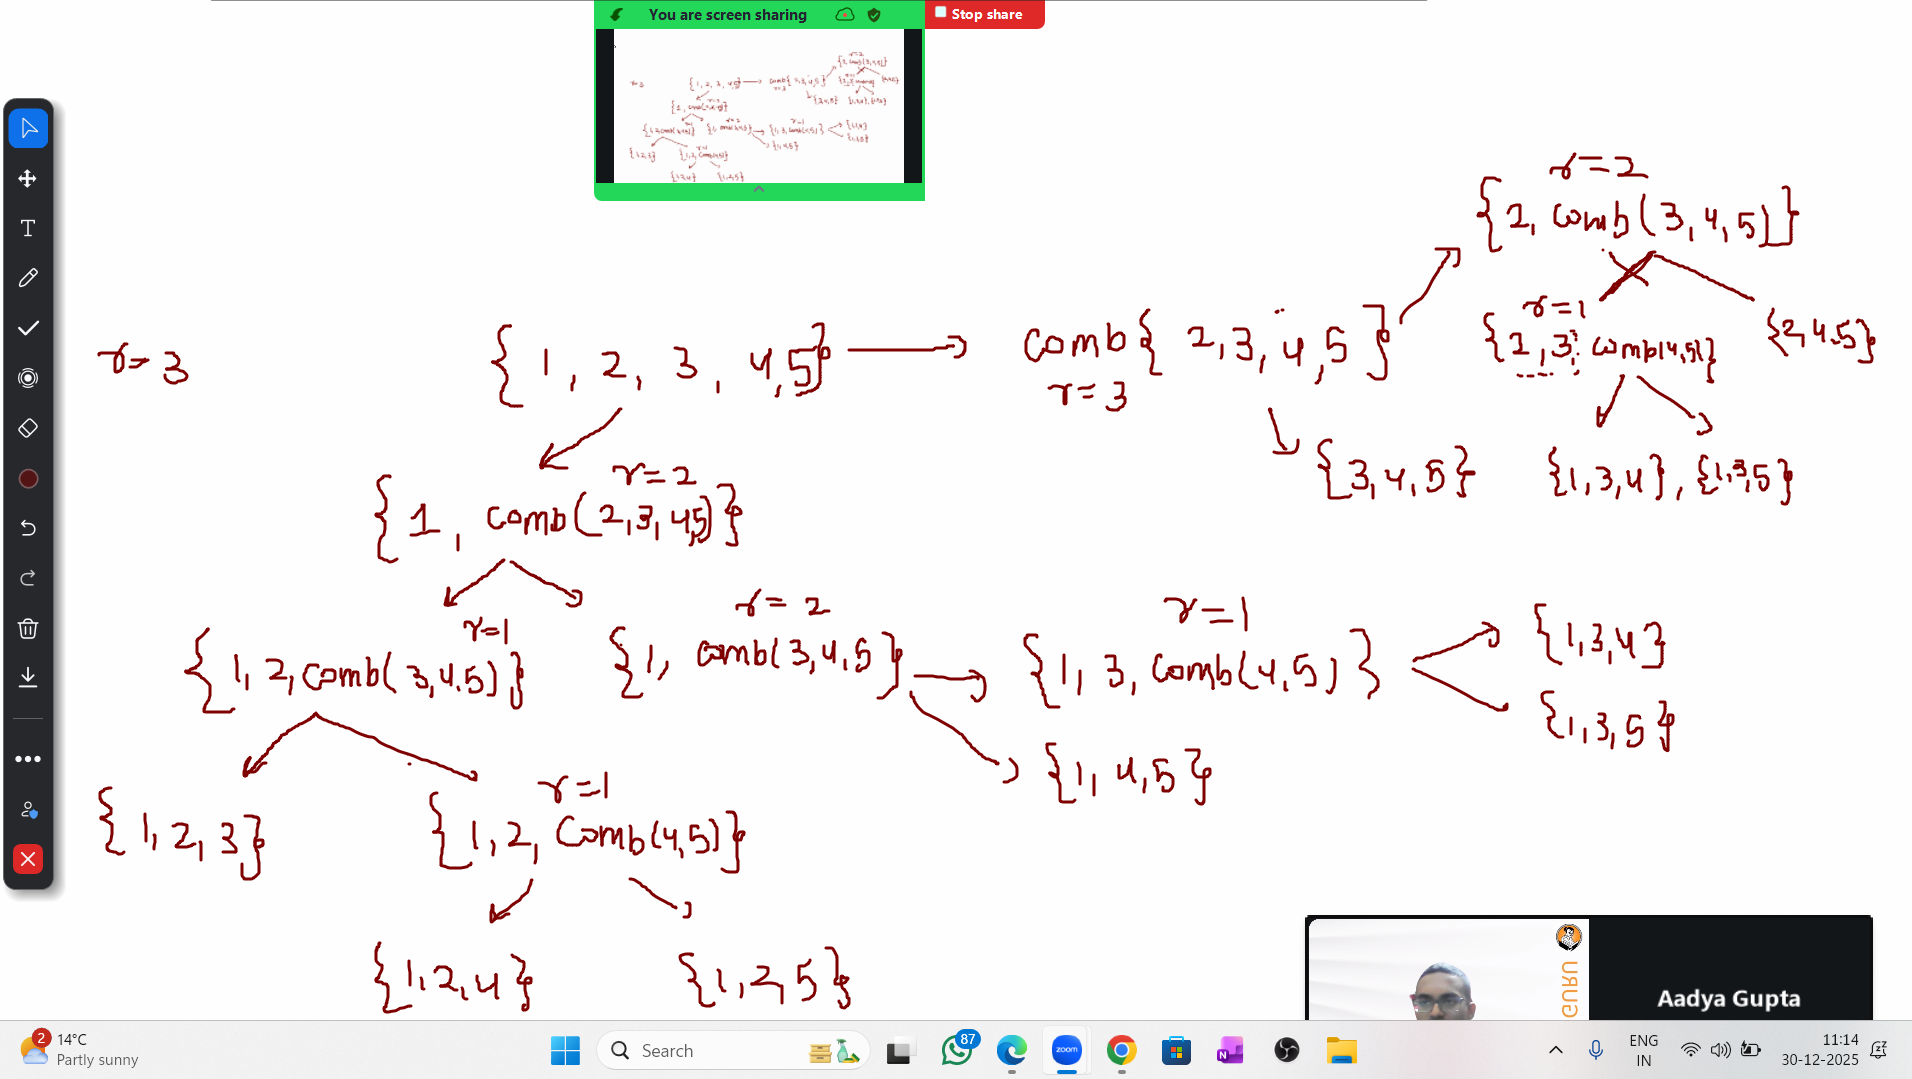

In [ ]:
def comb(l,r):
  if r>len(l) or r<=0:
    return []
  if r==1:
    return [[x] for x in l]

  with_first= [   [l[0]]  +  x for x in comb(l[1:],r-1) ]
  without_first = comb(l[1:],r)
  return with_first + without_first

In [ ]:
comb([1,2,3,4,5,6],3)

[[1, 2, 3],
 [1, 2, 4],
 [1, 2, 5],
 [1, 2, 6],
 [1, 3, 4],
 [1, 3, 5],
 [1, 3, 6],
 [1, 4, 5],
 [1, 4, 6],
 [1, 5, 6],
 [2, 3, 4],
 [2, 3, 5],
 [2, 3, 6],
 [2, 4, 5],
 [2, 4, 6],
 [2, 5, 6],
 [3, 4, 5],
 [3, 4, 6],
 [3, 5, 6],
 [4, 5, 6]]

In [ ]:
def comb(l, r):
    if r == 0:
        return [[]]
    if r > len(l):
        return []

    with_first = [[l[0]] + c for c in comb(l[1:], r-1)]
    without_first = comb(l[1:], r)

    return with_first + without_first


# **Q.8 Write a program to print all possible permutations of 'r' numbers from the set of first 'n' natural numbers where r<=n.**

For example: For $N = \{1,2,3\}$

When $n = 3$ and $r = 2$ :

$\{1,2\},\{2,1\},\{1,3\},\{3,1\},\{2,3\},\{3,2\}$

In [ ]:
def perm(l,r): # l is the list
  if r==0:
    return [[]]
  if r>len(l):
    return []
  without_first=perm(l[1:],r)
  with_first=[]

  for x in perm(l[1:],r-1):
    for i in range(len(x)+1):
      with_first.append(x[:i]+[l[0]]+x[i:])

  return with_first+without_first

In [ ]:
perm([1,2,3,4],3)

[[1, 2, 3],
 [2, 1, 3],
 [2, 3, 1],
 [1, 3, 2],
 [3, 1, 2],
 [3, 2, 1],
 [1, 2, 4],
 [2, 1, 4],
 [2, 4, 1],
 [1, 4, 2],
 [4, 1, 2],
 [4, 2, 1],
 [1, 3, 4],
 [3, 1, 4],
 [3, 4, 1],
 [1, 4, 3],
 [4, 1, 3],
 [4, 3, 1],
 [2, 3, 4],
 [3, 2, 4],
 [3, 4, 2],
 [2, 4, 3],
 [4, 2, 3],
 [4, 3, 2]]

In [ ]:
x=[1]
x[2:]

[]

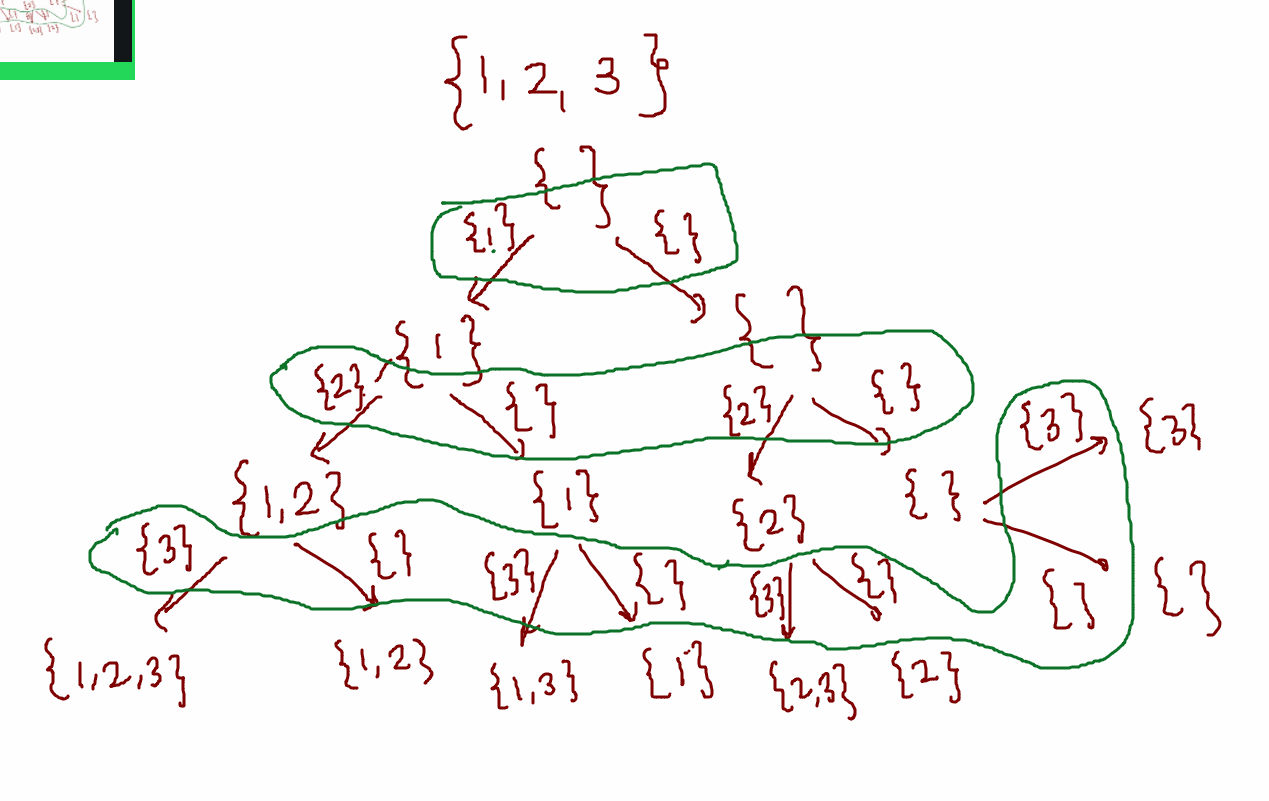

In [ ]:
[]+[2]

[2]

In [ ]:
def powerset(l, current=[[]], result=[[]]):

    if len(l) == 0:
        return result

    current=result.copy()

    first = [l[0]]

    for ele in current:
        result.append(first + ele)

    result.append([])

    powerset(l[1:], current, result)


In [ ]:
def powerset(l, result=None):
    if result is None:
        result = [[]]

    if len(l) == 0:
        return result

    current = result.copy()
    first = l[0]

    for ele in current:
        result.append(ele + [first])

    return powerset(l[1:], result)


In [ ]:
powerset([1,2,3,4,5])

[[],
 [1],
 [2],
 [1, 2],
 [3],
 [1, 3],
 [2, 3],
 [1, 2, 3],
 [4],
 [1, 4],
 [2, 4],
 [1, 2, 4],
 [3, 4],
 [1, 3, 4],
 [2, 3, 4],
 [1, 2, 3, 4],
 [5],
 [1, 5],
 [2, 5],
 [1, 2, 5],
 [3, 5],
 [1, 3, 5],
 [2, 3, 5],
 [1, 2, 3, 5],
 [4, 5],
 [1, 4, 5],
 [2, 4, 5],
 [1, 2, 4, 5],
 [3, 4, 5],
 [1, 3, 4, 5],
 [2, 3, 4, 5],
 [1, 2, 3, 4, 5]]

Q.9. Produce a sequence of $0$'s and $1's$ using backtracking

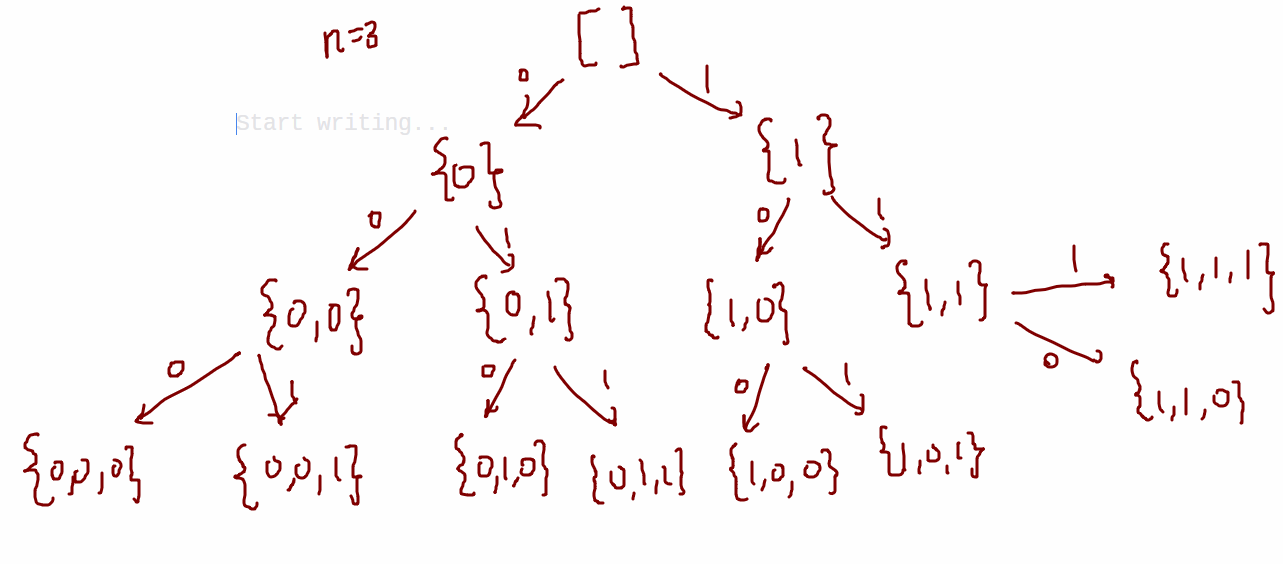

In [ ]:
def binary(n):
  result=[]
  current=[]
  def backtrack():
    if len(current)==n:
      result.append(current.copy())
      return

    for bit in (0,1):
      current.append(bit)
      backtrack()
      current.pop()
  backtrack()
  return result


In [ ]:
binary(3)

[[0, 0, 0],
 [0, 0, 1],
 [0, 1, 0],
 [0, 1, 1],
 [1, 0, 0],
 [1, 0, 1],
 [1, 1, 0],
 [1, 1, 1]]

Q.10 Binary Strings with No Consecutive 1s

Given an integer n, generate all binary strings of length n such that no two 1s appear consecutively.

In [ ]:
def binary(n):
  result=[]
  current = []

  def backtrack():
    if len(current)==n:
      result.append(current.copy())
      return
    for bit in(0,1):
      if current and current[-1] == 1 and bit ==1:
        # or return will also work in place of continue
        continue

      current.append(bit)
      backtrack()
      current.pop()
  backtrack()
  return result

In [ ]:
binary(4)

[[0, 0, 0, 0],
 [0, 0, 0, 1],
 [0, 0, 1, 0],
 [0, 1, 0, 0],
 [0, 1, 0, 1],
 [1, 0, 0, 0],
 [1, 0, 0, 1],
 [1, 0, 1, 0]]

Q.11 powerset problem using backtracking

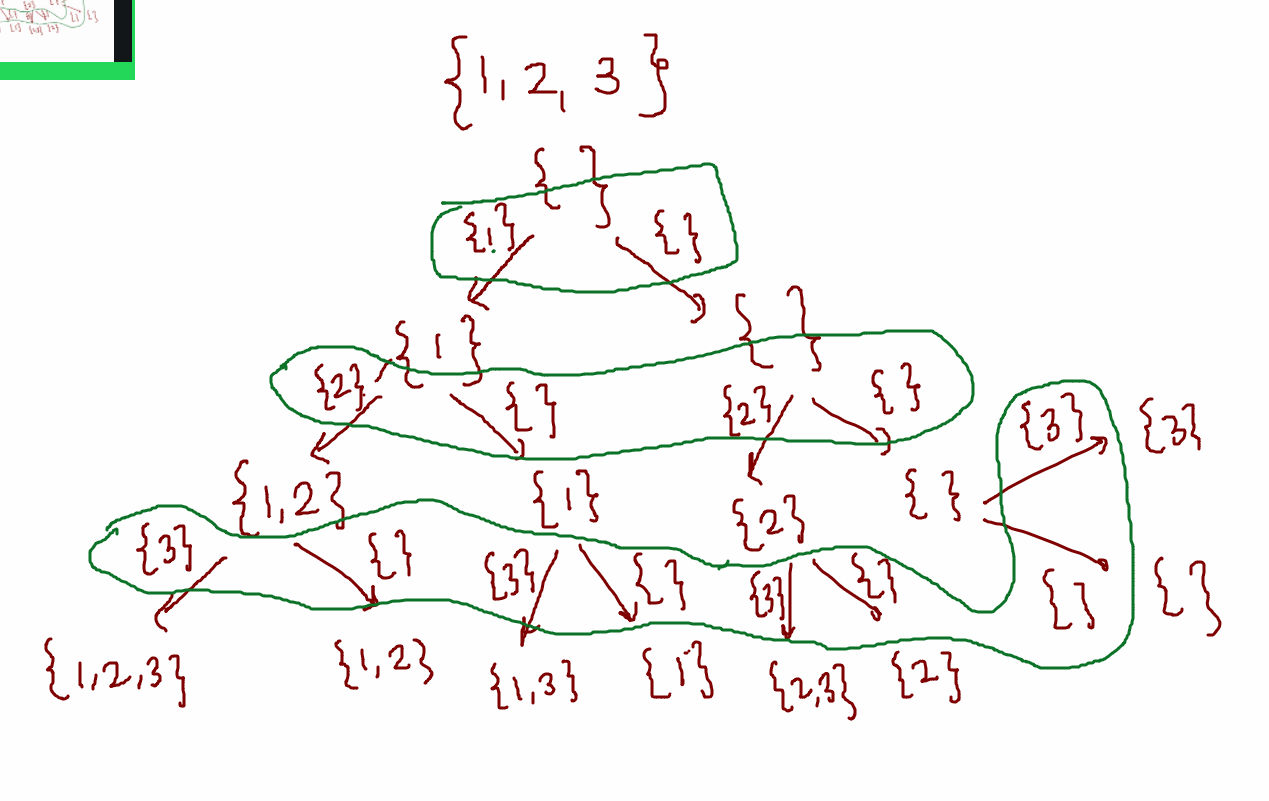

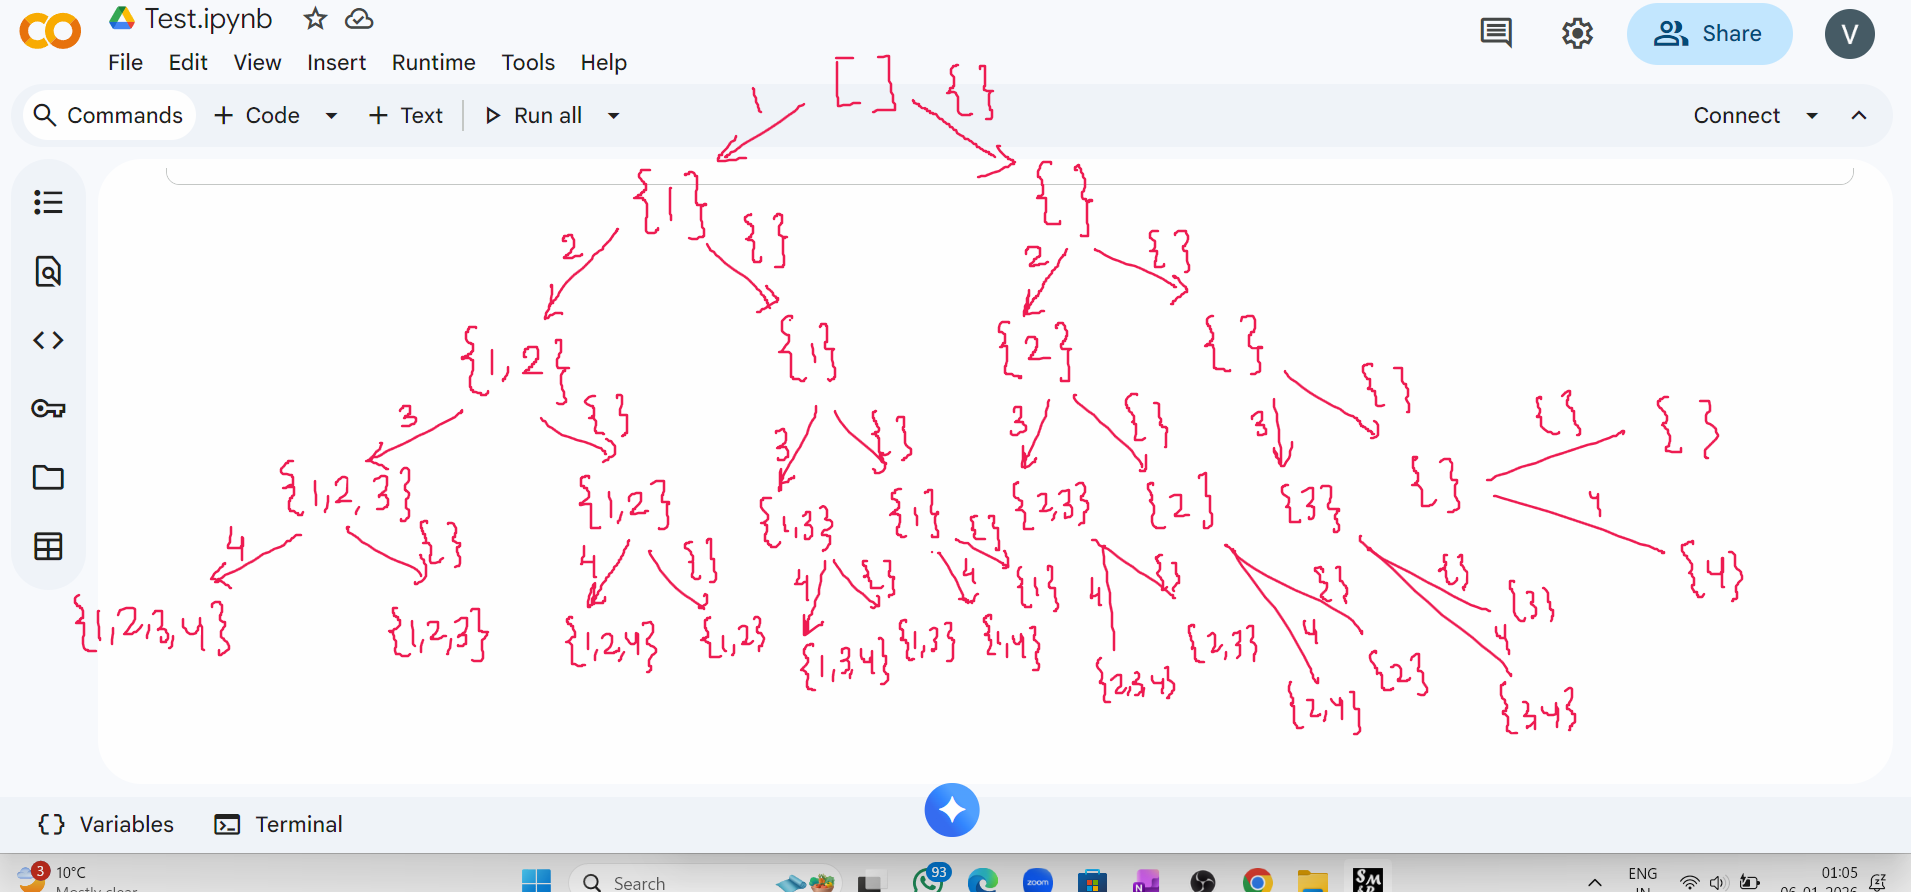

In [ ]:
def subsets(l):
  result=[]
  current=[]


  def backtrack(i):
    if i==len(l):
      result.append(current.copy())
      return

    current.append(l[i])
    backtrack(i+1)
    current.pop()
    backtrack(i+1)

  backtrack(0)
  return result


In [ ]:
subsets([1,2,3,4])

[[1, 2, 3, 4],
 [1, 2, 3],
 [1, 2, 4],
 [1, 2],
 [1, 3, 4],
 [1, 3],
 [1, 4],
 [1],
 [2, 3, 4],
 [2, 3],
 [2, 4],
 [2],
 [3, 4],
 [3],
 [4],
 []]

**Another way of doing this**

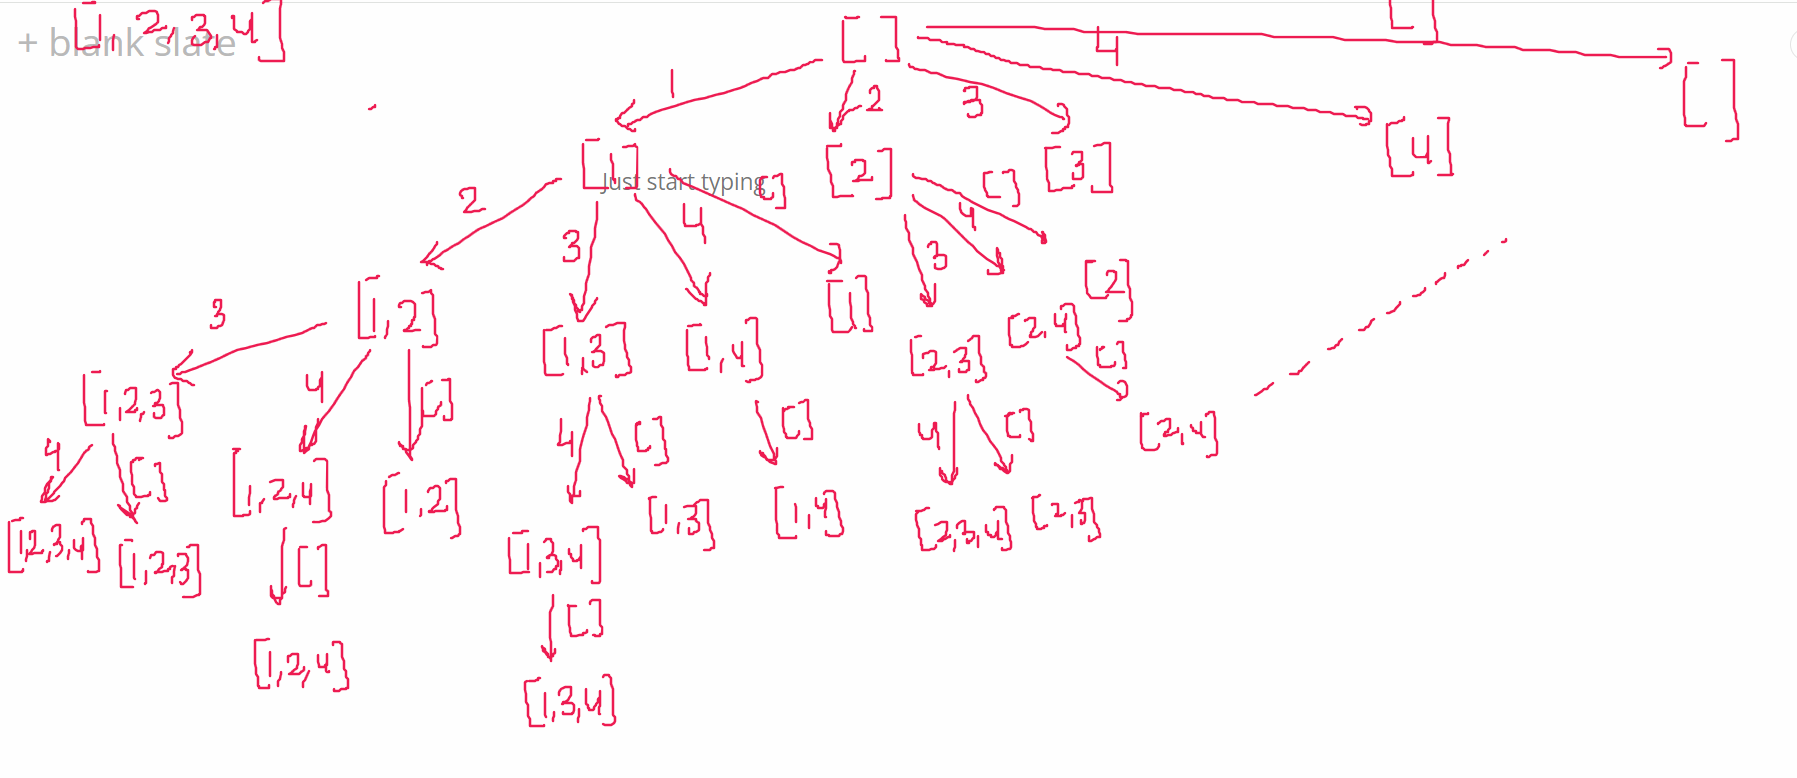

In [ ]:
def subsets(l):
    result = []
    current = []
    n = len(l)

    def backtrack(start):
        # every node is a valid subset
        result.append(current.copy())

        for i in range(start, n):
            current.append(l[i])
            backtrack(i + 1)
            current.pop()

    backtrack(0)
    return result


In [ ]:
subsets([1,2,3,4,5])

[[],
 [1],
 [1, 2],
 [1, 2, 3],
 [1, 2, 3, 4],
 [1, 2, 3, 4, 5],
 [1, 2, 3, 5],
 [1, 2, 4],
 [1, 2, 4, 5],
 [1, 2, 5],
 [1, 3],
 [1, 3, 4],
 [1, 3, 4, 5],
 [1, 3, 5],
 [1, 4],
 [1, 4, 5],
 [1, 5],
 [2],
 [2, 3],
 [2, 3, 4],
 [2, 3, 4, 5],
 [2, 3, 5],
 [2, 4],
 [2, 4, 5],
 [2, 5],
 [3],
 [3, 4],
 [3, 4, 5],
 [3, 5],
 [4],
 [4, 5],
 [5]]

# **Q.12. Given a list of distinct integers nums and an integer k, generate all subsets of size exactly k.**

nums = [1, 2, 3, 4]

k = 2


**Ineffecient Pruning**

In [ ]:
def combinations(l,k):
  current=[]
  result=[]
  n = len(l) # 0 1 2 3 4 5 6 7
  if k > n:
    return

  def backtrack(i):
    if i == len(l):
      if len(current)==k:
        result.append(current.copy())
      return
    if i>n-k and current==[]:
      return

    current.append(l[i])
    backtrack(i+1)
    current.pop()
    backtrack(i+1)
  backtrack(0)
  return result


**Effecient Pruning**

In [ ]:
def combinations(l,k):
  current=[]
  result=[]
  n = len(l) # 0 1 2 3 4 5 6 7
  if k > n:
    return

  def backtrack(i):
    if i == len(l):
      if len(current)==k:
        result.append(current.copy())
      return
    if len(current)+n-i<k:
      return

    current.append(l[i])
    backtrack(i+1)
    current.pop()
    backtrack(i+1)
  backtrack(0)
  return result


In [ ]:
combinations([1,2,3,4,5],3)

[[1, 2, 3],
 [1, 2, 4],
 [1, 2, 5],
 [1, 3, 4],
 [1, 3, 5],
 [1, 4, 5],
 [2, 3, 4],
 [2, 3, 5],
 [2, 4, 5],
 [3, 4, 5]]

In [ ]:
[]+[2]

[2]

Q.13 Permutations using backtracking

In [ ]:
def permutations(l,k):
  current=[]
  result=[]
  n = len(l)
  if k > n:
    return []

  def backtrack():
    if len(current)==k:
      result.append(current.copy())
      return
    for x in l:
      if x in current:
        continue
      current.append(x)
      backtrack()
      current.pop()
  backtrack()
  return result

In [ ]:
permutations([1,2,3,4],2)

[[1, 2],
 [1, 3],
 [1, 4],
 [2, 1],
 [2, 3],
 [2, 4],
 [3, 1],
 [3, 2],
 [3, 4],
 [4, 1],
 [4, 2],
 [4, 3]]

In [ ]:
def permutations(l, k):
    if k > len(l):
        return []

    n = len(l)
    used = [False] * n
    current = []
    result = []

    def backtrack():
        if len(current) == k:
            result.append(current.copy())
            return

        for i in range(n):
            if used[i]:
                continue
            used[i] = True
            current.append(l[i])
            backtrack()
            current.pop()
            used[i] = False

    backtrack()
    return result


In [ ]:
"""
                          []
              /             |             \
            1               2               3
           / \             / \             / \
          2   3           1   3           1   2
         /     \         /     \         /     \
        3       2       3       1       2       1

     [1,2,3] [1,3,2] [2,1,3] [2,3,1] [3,1,2] [3,2,1]
"""

In [ ]:
"""
                                  []
                /                  |                 \
              1                     2                 3
      /       |       \
     2        3        4
   /   \    /  \      / \
   3   4   2    4    2   3

     [1,2,3] [1,3,2] [2,1,3] [2,3,1] [3,1,2] [3,2,1]
"""

In [ ]:
"""
 []
├── 1
│   ├── 2
│   │   ├── 3
│   │   │   └── 4   → [1,2,3,4]
│   │   └── 4
│   │       └── 3   → [1,2,4,3]
│   ├── 3
│   │   ├── 2
│   │   │   └── 4   → [1,3,2,4]
│   │   └── 4
│   │       └── 2   → [1,3,4,2]
│   └── 4
│       ├── 2
│       │   └── 3   → [1,4,2,3]
│       └── 3
│           └── 2   → [1,4,3,2]
│
├── 2
│   ├── 1
│   │   ├── 3
│   │   │   └── 4   → [2,1,3,4]
│   │   └── 4
│   │       └── 3   → [2,1,4,3]
│   ├── 3
│   │   ├── 1
│   │   │   └── 4   → [2,3,1,4]
│   │   └── 4
│   │       └── 1   → [2,3,4,1]
│   └── 4
│       ├── 1
│       │   └── 3   → [2,4,1,3]
│       └── 3
│           └── 1   → [2,4,3,1]
│
├── 3
│   ├── 1
│   │   ├── 2
│   │   │   └── 4   → [3,1,2,4]
│   │   └── 4
│   │       └── 2   → [3,1,4,2]
│   ├── 2
│   │   ├── 1
│   │   │   └── 4   → [3,2,1,4]
│   │   └── 4
│   │       └── 1   → [3,2,4,1]
│   └── 4
│       ├── 1
│       │   └── 2   → [3,4,1,2]
│       └── 2
│           └── 1   → [3,4,2,1]
│
└── 4
    ├── 1
    │   ├── 2
    │   │   └── 3   → [4,1,2,3]
    │   └── 3
    │       └── 2   → [4,1,3,2]
    ├── 2
    │   ├── 1
    │   │   └── 3   → [4,2,1,3]
    │   └── 3
    │       └── 1   → [4,2,3,1]
    └── 3
        ├── 1
        │   └── 2   → [4,3,1,2]
        └── 2
            └── 1   → [4,3,2,1]
"""


In [ ]:
"""
So, can this be treated as full and final proof.

    def backtrack():
        if sum(current)==target:
            result.append(current.copy())
            return
        # some code

            backtrack()
            current.pop()


" Frame N knows the correct value will be popped because all deeper frames are
required to restore the list to the state it had at their entry, leaving frame
N’s appended element as the last element when control returns. " can be
justified because of this.

Each frame has an append followed by a backtrack() again followed by a pop. Lets
 say the recursion terminates at the (N+k)th frame, At that stage, because of
 the base case, backtrack() is returned a null value and then the appended value
  is popped off.

So, the terminating stage i.e. the N+k th stage did not change the value of
current at all => the N+k-1 which consists of a append, backtrack() (which will
 open N+k frame but doesnt mutate current at all),and then a pop shall also not
 change the value of  current. By induction, the value of current is not changed
  at all at any inductive step.

All this is possible because the the base case at the N+k th step does not
change the value of current because it is encountered before any append or
mutating statement. Had the base case changed the value of the current, things
would have been different as current will then change at each frame.
"""

# **Q.14 39. Combination Sum**

Given an array of distinct integers candidates and a target integer target, return a list of all unique combinations of candidates where the chosen numbers sum to target. You may return the combinations in any order.

The same number may be chosen from candidates an unlimited number of times. Two combinations are unique if the frequency of at least one of the chosen numbers is different.

The test cases are generated such that the number of unique combinations that sum up to target is less than 150 combinations for the given input.



Example 1:

Input: candidates = [2,3,6,7], target = 7

Output: [[2,2,3],[7]]

Explanation:

2 and 3 are candidates, and 2 + 2 + 3 = 7. Note that 2 can be used multiple times.

7 is a candidate, and 7 = 7.

These are the only two combinations.

Example 2:

Input: candidates = [2,3,5], target = 8

Output: [[2,2,2,2],[2,3,3],[3,5]]

Example 3:

Input: candidates = [2], target = 1

Output: []


Constraints:

1 <= candidates.length <= 30

2 <= candidates[i] <= 40

All elements of candidates are distinct.

1 <= target <= 40

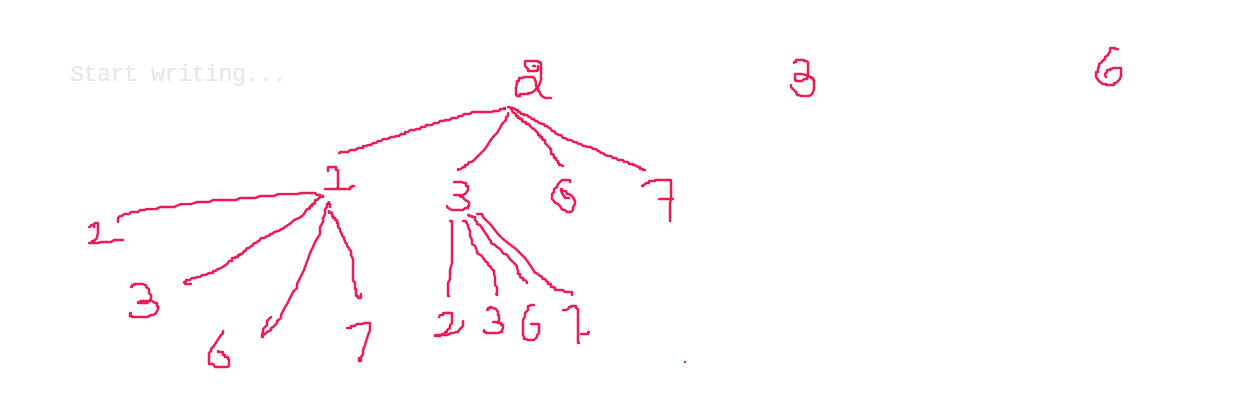

# **This produces without repetition**

In [ ]:
def combinationSum(candidates, target):
    current=[]
    result=[]
    n = len(candidates)

    def backtrack(i):
        if sum(current)==target:
            result.append(current.copy())
            return

        for j in range(i,n):
            current.append(candidates[j])
            if sum(current)>target:
                current.pop()
                continue
            backtrack(j)
            current.pop()
    backtrack(0)
    return result

# **More Effecient Solution**

In [ ]:
def backtrack(i, remaining):
    if remaining == 0:
        result.append(current.copy())
        return

    for j in range(i, n):
        if candidates[j] > remaining:
            break
        current.append(candidates[j])
        backtrack(j, remaining - candidates[j])
        current.pop()


In [ ]:
combinationSum([2,3,6,7],7)

[[2, 2, 3], [7]]

In [ ]:
combinationSum([2,3,5],8)

[[2, 2, 2, 2], [2, 3, 3], [3, 5]]

# **With repetition**

In [ ]:
def combinationSum(candidates, target):

    current=[]
    result=[]
    n = len(candidates)

    def backtrack():
        if sum(current)==target:
            result.append(current.copy())
            return

        for x in candidates:
            current.append(x)
            if sum(current)>target:
                current.pop()
                continue
            backtrack()
            current.pop()
    backtrack()
    return result

In [ ]:
combinationSum([2,3,6,7],7)

[[2, 2, 3], [2, 3, 2], [3, 2, 2], [7]]

In [ ]:
combinationSum([2,3,5],8)

[[2, 2, 2, 2], [2, 3, 3], [3, 2, 3], [3, 3, 2], [3, 5], [5, 3]]

# **Q.15 RAT IN A MAZE (BACKTRACKING PROBLEM)**

This is a classic backtracking + grid traversal problem.

❓ Problem Statement

You are given an $n × n$ grid (maze) where:

1 → open cell (can move)

0 → blocked cell (cannot move)

A rat starts at the top-left corner (0, 0) and wants to reach the bottom-right corner (n-1, n-1).

The rat is allowed to move only:

Down → (i+1, j) represented by 'D'

Right → (i, j+1) represented by 'R'

🎯 Task

Print all possible paths from the start to the destination.

Each path should be represented as a string consisting of:

'D' for down

'R' for right

📌 Example

Input Maze

maze = [

    [1, 0, 0, 0],

    [1, 1, 0, 1],

    [0, 1, 0, 0],
    
    [1, 1, 1, 1]
]

Valid Output
DDRDRR
DRDDRR


(Order does not matter.)

# **Q.16 . 797. All Paths From Source to Target**

Given a directed acyclic graph (DAG) of n nodes labeled from 0 to n - 1, find all possible paths from node 0 to node n - 1 and return them in any order.

The graph is given as follows: graph[i] is a list of all nodes you can visit from node i (i.e., there is a directed edge from node i to node graph[i][j]).



Example 1:

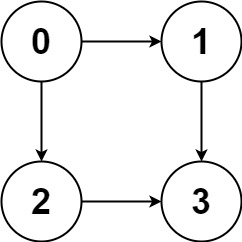


Input: graph = [[1,2],[3],[3],[]]

Output: [[0,1,3],[0,2,3]]

Explanation: There are two paths: 0 -> 1 -> 3 and 0 -> 2 -> 3.

Example 2:

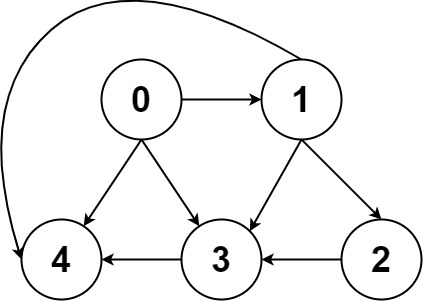

Input: graph = [[4,3,1],[3,2,4],[3],[4],[]]

Output: [[0,4],[0,3,4],[0,1,3,4],[0,1,2,3,4],[0,1,4]]


Constraints:

n == graph.length

2 <= n <= 15

0 <= graph[i][j] < n

graph[i][j] != i (i.e., there will be no self-loops).

All the elements of graph[i] are unique.

The input graph is guaranteed to be a DAG.

In [ ]:
class Solution:
    def allPathsSourceTarget(self, graph: List[List[int]]) -> List[List[int]]:
        current=[0]
        result=[]
        n = len(graph)

        def backtrack(i):
            if i == n-1:
                result.append(current.copy())
                return

            if graph[i]==[]:
                return

            for j in graph[i]:
                current.append(j)
                backtrack(j)
                current.pop()
        backtrack(0)
        return result

# **Q.17. 1458. Max Dot Product of Two Subsequences**
Hard

Given two arrays nums1 and nums2.

Return the maximum dot product between non-empty subsequences of nums1 and nums2 with the same length.

A subsequence of a array is a new array which is formed from the original array by deleting some (can be none) of the characters without disturbing the relative positions of the remaining characters. (ie, [2,3,5] is a subsequence of [1,2,3,4,5] while [1,5,3] is not).



**Example 1:**

Input: **nums1** = $[2,1,-2,5]$, **nums2** = $[3,0,-6]$

Output: 18

Explanation: Take subsequence [2,-2] from nums1 and subsequence [3,-6] from nums2.

Their dot product is (2*3 + (-2)*(-6)) = 18.

**Example 2:**

Input: **nums1** = $[3,-2]$, **nums2** = $[2,-6,7]|$

Output: 21

Explanation: Take subsequence [3] from nums1 and subsequence [7] from nums2.

Their dot product is (3*7) = 21.

**Example 3:**

Input: **nums1** = $[-1,-1]$, **nums2** = $[1,1]$

Output: -1

Explanation: Take subsequence [-1] from nums1 and subsequence [1] from nums2.

Their dot product is -1.


Constraints: **bold text**

1 <= nums1.length, nums2.length <= 500

-1000 <= nums1[i], nums2[i] <= 1000

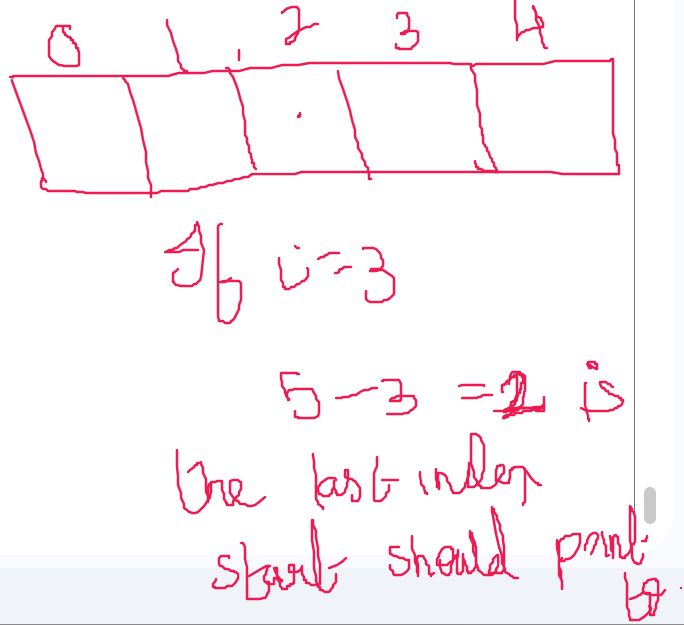

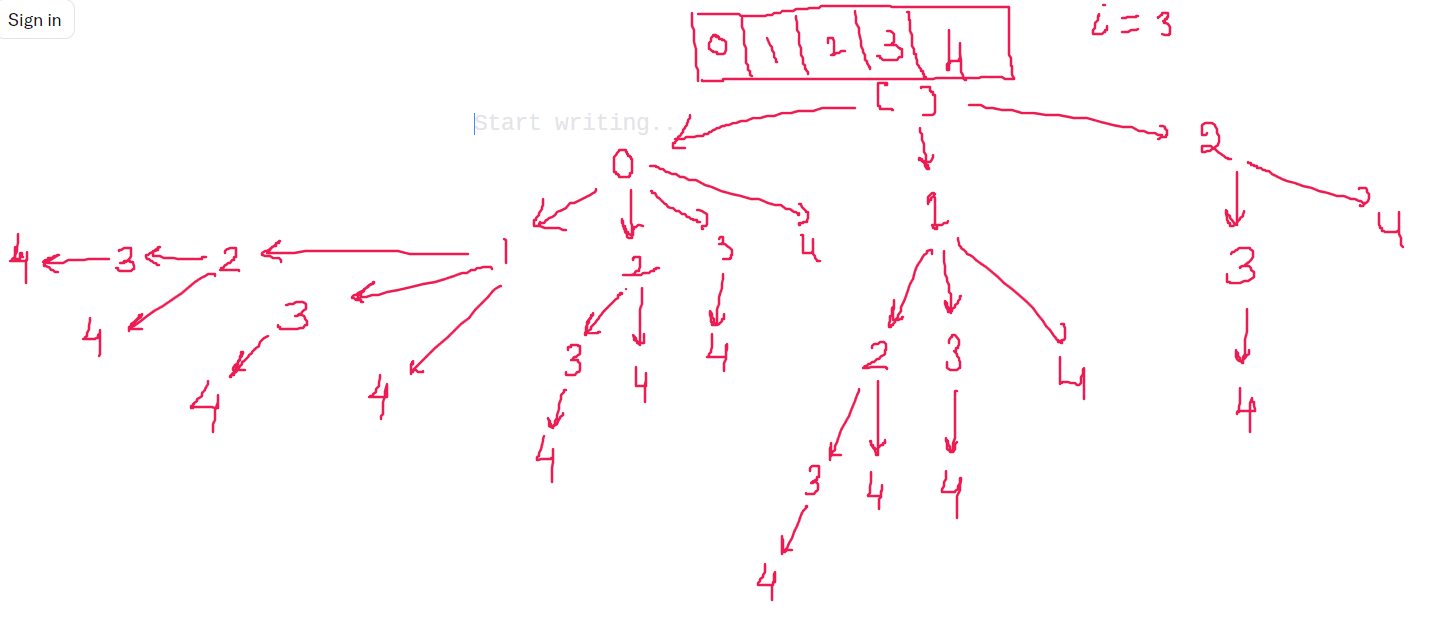

# **(a) Without dynamic programming**

In [ ]:
# Input: nums1 = [2,1,−2,5], nums2 = [3,0,−6]
# Output: 18
# Explanation: Take subsequence [2,-2] from nums1 and subsequence [3,-6] from nums2.
# Their maximum possible dot product is (23 + (-2)(-6)) = 18.

def maxDotProduct(nums1, nums2):
  n1 = len(nums1)
  n2 = len(nums2)
  n = min(n1,n2)
  #print("n= ", n ,n1,n2)
  current1=[]
  current2=[]
  result1=[]
  result2=[]
  result=[]

  def dotproduct(nums1,nums2):
    sum =0
    for index in range(len(nums1)):
      sum += nums1[index]*nums2[index]
    return sum

  def backtrack1(i): # i stores the length of sequences dot multiplying
    if i==n+1:
      return

    def backtrack2(start):
      if len(current1)==i:
        result1.append(current1.copy())
        #print(current1)
        return


      if n1 - start < i - len(current1):
          return


      for j in range(start,n1):
        current1.append(nums1[j])
        backtrack2(j+1)
        current1.pop()

    def backtrack3(start):
      if len(current2)==i:
        result2.append(current2.copy())
        #print(current2)
        return

      if n2 - start < i - len(current2):
          return


      for j in range(start,n2):
        current2.append(nums2[j])
        backtrack3(j+1)
        current2.pop()

    backtrack2(0)
    backtrack3(0)
    backtrack1(i+1)
  backtrack1(1)

  # print("hi1 ",result1)
  # print("hi2 ", result2)

  for x in result1:
    for y in result2:
      if len(y) != len(x):
        continue
      result.append(dotproduct(x,y))
  return max(result)

In [ ]:
maxDotProduct( [2,1,-2,5], [3,0,-6])

18

# **(B) With dynamic programming**

In [ ]:
def maxDotProduct(nums1, nums2):
    n1, n2 = len(nums1), len(nums2)

    dp = [[float('-inf')] * (n2 + 1) for _ in range(n1 + 1)]

    for i in range(1, n1 + 1):
        for j in range(1, n2 + 1):
            prod = nums1[i-1] * nums2[j-1]
            dp[i][j] = max(
                prod,                 # start new subsequence
                prod + dp[i-1][j-1],  # extend
                dp[i-1][j],           # skip nums1[i-1]
                dp[i][j-1]            # skip nums2[j-1]
            )

    return dp[n1][n2]

In [ ]:
maxDotProduct( [3,-2], [2,-6,7])

21

In [ ]:
maxDotProduct( [-1,-1], [1,1])

-1

In [ ]:
# 1. All negative numbers
maxDotProduct(
    [-5, -4, -3],
    [-1, -2]
)
# Expected: 13


13

In [ ]:
# 2. Mixed signs, best answer is a single pair
maxDotProduct(
    [7, -5, 2, -3],
    [-6, 4, -1]
)
# Expected: 28


41

# **Using Dynamic Programming** : Here $dp[i][j]$ is the maximum dot product achievable by pairing elements of two subsequences that must include the pair(nums$1 [i]$, nums$2[j])$ as their final pairing, with all earlier pairings taken from strictly smaller indices.

In [ ]:
def maxDotProduct(nums1, nums2):
    n1, n2 = len(nums1), len(nums2)
    dp = [[float('-inf')] * n2 for _ in range(n1)]
    ans = float('-inf')

    for i in range(n1):
        for j in range(n2):
            prod = nums1[i] * nums2[j]
            if i > 0 and j > 0:
                dp[i][j] = max(prod, dp[i-1][j-1] + prod)
            else:
                dp[i][j] = prod
            ans = max(ans, dp[i][j])

    return ans


Q.18 You are given coins $[1, 3, 4].$
Find the minimum number of coins to make amount $6.$

In [ ]:
"""
Let dp[x] represent the minimum number of coins required to make the amount of
x. Then dp[x] = min ( dp[x-1]+1, dp[x-3]+1, dp[x-4]+1)
"""

def minimumCoins(amount):
  dp = [float('inf') for _ in range(amount+1)]
  dp[0]=0
  dp[1]=1
  dp[2]=2
  dp[3]=1
  dp[4]=1

  if amount<0:
    return 0
  if amount in range(0,5):
    return dp[amount]

  for i in range(5,amount+1):
    dp[i] = min(dp[max(i-1,0)], dp[max(i-3,0)], dp[max(i-4,0)]) + 1
  return dp[amount]

In [ ]:
minimumCoins(10)

3

In [ ]:
tests = [
    (0, 0),
    (1, 1),
    (2, 2),
    (3, 1),
    (4, 1),
    (5, 2),
    (6, 2),
    (7, 2),
    (8, 2),
    (10, 3)
]

for amount, expected in tests:
    print(amount, minimumCoins(amount), expected)


IndexError: list assignment index out of range

In [ ]:
def minimumCoins(amount):
    coins = [1, 3, 4]
    dp = [float('inf')] * (amount + 1)
    dp[0] = 0

    for i in range(1, amount + 1):
        for c in coins:
            if i - c >= 0:
                dp[i] = min(dp[i], dp[i - c] + 1)

    return dp[amount]


# Q.19 Longest common subsequence
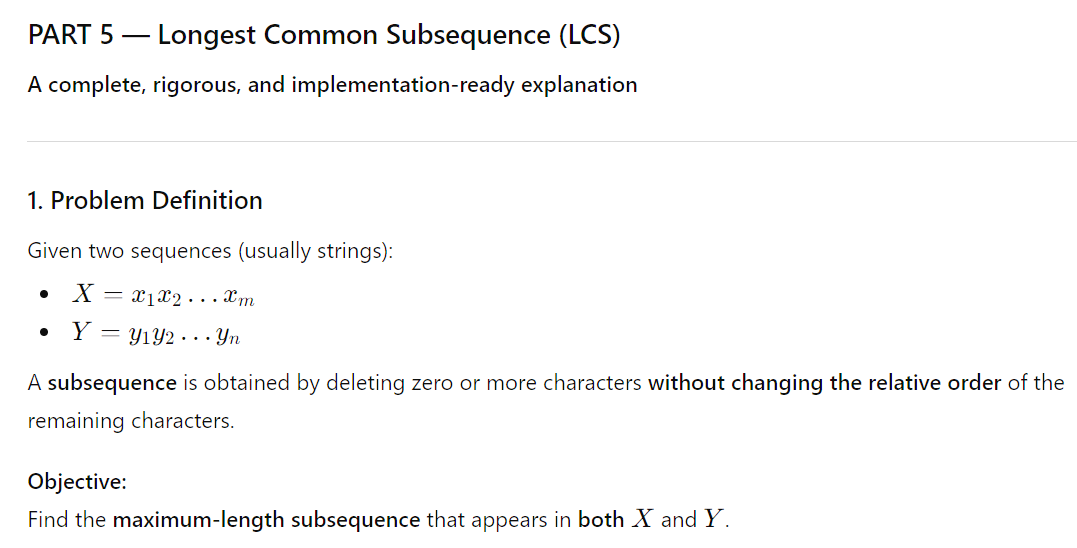

In [ ]:
"""
Define L[i,j] = length of maximum subsequence while considering the sequences
x[0:i+1] and y[0:j+1]
"""
def lcs_length(X, Y):
  if not X or not Y:
    return 0
  n1 = len(X)
  n2 = len(Y)
  n = min(n1,n2)

  dp = [ [ 0 for _ in range(n2)] for __ in range(n1)]

  if X[0]==Y[0]:
    dp[0][0]=1

  # Initialize first row
  for j in range(1, n2):
      if X[0] == Y[j]:
          dp[0][j] = 1
      else:
          dp[0][j] = dp[0][j-1]

  # Initialize first column
  for i in range(1, n1):
      if X[i] == Y[0]:
          dp[i][0] = 1
      else:
          dp[i][0] = dp[i-1][0]


  #L[i,j] =   L[i-1,j-1]+1 if X[i]=Y[j]
  #       =   max(L[i-1,j], L[i,j-1] ) if X[i] != Y[j]

  for i in range(1,n1):
    for j in range(1,n2):
      if X[i]==Y[j]:
        dp[i][j]=1+dp[i-1][j-1]
      else:
        dp[i][j] = max(dp[i-1][j], dp[i][j-1])

  return dp[n1-1][n2-1]

In [ ]:
test_cases = [
    # 1. Classic textbook example
    ("ABCBDAB", "BDCABA", 4),

    # 2. Identical strings
    ("AGGTAB", "AGGTAB", 6),

    # 3. One string empty
    ("ABC", "", 0),

    # 4. No common characters
    ("ABC", "DEF", 0),

    # 5. Single-character match
    ("A", "A", 1),

    # 6. Single-character no match
    ("A", "B", 0),

    # 7. Repeated characters
    ("AAAA", "AA", 2),

    # 8. Interleaved subsequence
    ("XMJYAUZ", "MZJAWXU", 4),

    # 9. One string is a subsequence of the other
    ("ABCDE", "ACE", 3),

    # 10. Case with multiple optimal subsequences
    ("ABCDEF", "FBDAMN", 2),
]

# -------------------------------
# Run Tests
# -------------------------------

for i, (s1, s2, expected) in enumerate(test_cases, 1):
    result = lcs_length(s1, s2)
    print(f"Test {i}: LCS('{s1}', '{s2}') = {result} | Expected = {expected}")

Test 1: LCS('ABCBDAB', 'BDCABA') = 4 | Expected = 4
Test 2: LCS('AGGTAB', 'AGGTAB') = 6 | Expected = 6
Test 3: LCS('ABC', '') = 0 | Expected = 0
Test 4: LCS('ABC', 'DEF') = 0 | Expected = 0
Test 5: LCS('A', 'A') = 1 | Expected = 1
Test 6: LCS('A', 'B') = 0 | Expected = 0
Test 7: LCS('AAAA', 'AA') = 2 | Expected = 2
Test 8: LCS('XMJYAUZ', 'MZJAWXU') = 4 | Expected = 4
Test 9: LCS('ABCDE', 'ACE') = 3 | Expected = 3
Test 10: LCS('ABCDEF', 'FBDAMN') = 2 | Expected = 2


# **Q.20 Fibonacci using memoization**

**(a) Top Down approach**

In [ ]:
def fib(n):
  memo={1:1,2:1}
  def fun(n):
    if n in memo:
      return memo[n]
    else:
      memo[n] = fun(n-1)+fun(n-2)
    return memo[n]
  return fun(n)

In [ ]:
fib(100)

354224848179261915075

**(b) Bottom up approach**

In [ ]:
def fib(n):
    if n <= 2:
        return 1

    dp = [0] * (n + 1)
    dp[1] = dp[2] = 1

    for i in range(3, n + 1):
        dp[i] = dp[i-1] + dp[i-2]

    return dp[n]


# **Q.21  0/1 Knapsack problem**

**1. What the Problem Is Actually About**

You are given a finite set of items.
Each item has two attributes:

a weight (how much space it occupies)

a value (how much benefit it gives)

You also have a knapsack (a container) with a fixed maximum capacity W.

Your task is to decide which items to put into the knapsack.

2. The Two Hard Constraints
Constraint 1 — Capacity

The sum of the weights of the selected items must not exceed W.

You cannot:

(a) exceed the capacity

(b) partially include an item to make it fit

(c) Constraint 2 — 0/1 Choice (This Is Crucial)

Each item has exactly two options:

0 → do not take the item

1 → take the item once

You cannot:

take an item more than once

take a fraction of an item

This is why it is called 0/1 Knapsack.

3. What You Are Optimizing

Among all valid selections of items that satisfy the capacity constraint, you want the one with:

maximum total value

Not:

maximum number of items

minimum weight

best value-to-weight ratio

Only total value matters.

4. Why This Is Not Trivial

Suppose you have 30 items.

Each item can be either taken or not taken

That gives
2
30
2
30
 possible subsets

Brute force is infeasible

So you need a systematic way to explore possibilities without enumerating all subsets.

5. Why Greedy Intuition Fails

A natural thought is:

“Take the item with highest value first.”

or

“Take the item with best value/weight ratio first.”

Both can fail.

Example
weights = [10, 20, 30]
values  = [60, 100, 120]
W = 50


Greedy by value/weight ratio picks:

item 1 (ratio 6)

item 2 (ratio 5)

Total:

weight = 30
value = 160


But the optimal choice is:

item 2 and item 3

Total:

weight = 50
value = 220


So local decisions do not lead to global optimality.

# **Q. 22** **Maximum Sum with No Adjacent Elements**
**Problem**
Given an array of non-negative integers, find the maximum sum such that no two chosen elements are adjacent.







In [ ]:
"""
maxSum([3,2,5,10,7])      # 15
maxSum([5,1,1,5])         # 10
maxSum([2,7,9,3,1])       # 12
maxSum([10])              # 10
maxSum([])                # 0 """

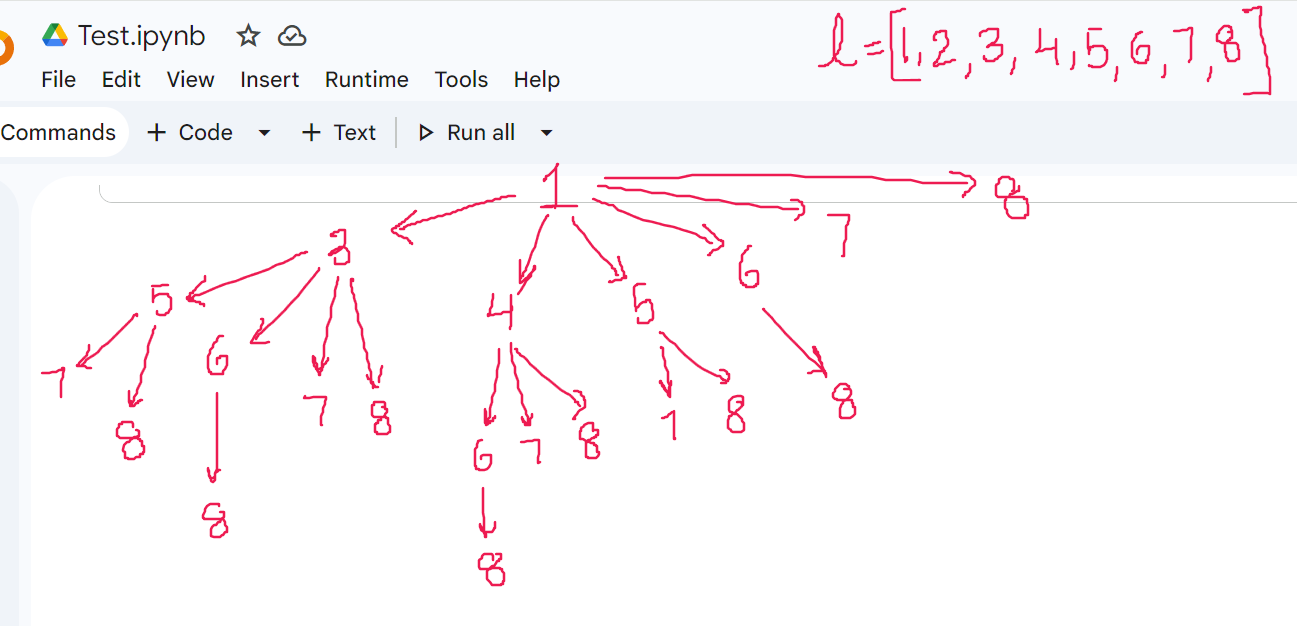

# **Self using backtracking**

In [ ]:
def maxsum(l):
  n=len(l)
  if n==0:
    return 0
  if n==1:
    return l[0]
  if n==2:
    return max(l[0],l[1])
  best=0

  def backtrack(start,current):
    nonlocal best
    for i in range(start+2,n):
      current+=l[i]
      if i==n-1 or i==n-2:
        best=max(best,current)
      backtrack(i,current)
      current-=l[i]

  backtrack(0,l[0])
  temp1=best
  backtrack(1,l[1])
  return max(temp1,best)

In [ ]:
maxsum([5, 5, 10, 100, 10, 5])

110

In [ ]:
test_cases = [
    # Edge / minimal
    ([0], 0), ([5], 5), ([0, 0], 0),  ([1, 2], 2),
    # Small but tricky
    ([2, 1, 1], 3),          # 2 + 1
    ([1, 2, 3], 4),          # 1 + 3
    ([3, 2, 5], 8),          # 3 + 5
    ([5, 1, 1], 6),          # 5 + 1
    # Non-trivial branching
    ([1, 100, 1, 1], 101),   # 100 + 1
    ([1, 2, 9, 4, 5], 15),   # 1 + 9 + 5
    ([4, 1, 1, 4, 2], 6),    # 4 + 2
    ([10, 2, 2, 100, 2], 110), # 10 + 100
    # Greedy failures
    ([5, 5, 10, 100, 10, 5], 110),  # 5 + 100 + 5
    ([3, 2, 7, 10], 13),            # 3 + 10
    ([3, 2, 5, 10, 7], 15),          # 3 + 5 + 7
    ([1, 20, 3, 30, 2, 50], 100),    # 20 + 30 + 50

    # Longer / deeper branching
    ([1, 2, 3, 1, 5, 8, 4], 15),     # 2 + 5 + 8
    ([8, 1, 1, 9, 1, 1, 8], 25),     # 8 + 9 + 8
    ([4, 10, 3, 1, 5, 15, 3, 2], 27),# 10 + 15 + 2
    ([2, 7, 9, 3, 1, 5, 8, 4], 24),  # 2 + 9 + 1 + 8 + 4
]
# -------------------- RUN TESTS --------------------

for i, (arr, expected) in enumerate(test_cases, 1):
    result = maxsum(arr)
    status = "PASS" if result == expected else "FAIL"
    print(f"Test {i:02d}: {arr} -> {result} | Expected: {expected} | {status}")

# **Memoization-This works only for an array with non negative numbers**

In [ ]:
'''
Let dp[i] = maximum sum of the subsequence that originates at the index i
Then dp[i]= l[i] + max ( dp[i+2], dp[i+3], ... , dp[n-1])

Let Mi = max (dp[i], dp[i+1], ..., dp[n-1])
dp[i] = l[i] + M_i+2
dp[i-1]= l[i-1] + M_i+1

######################
dp[i] = maximum sum of the subsequence from the ith index onwards.
Then dp[i]= l[i] + max ( dp[i+2], dp[i+3], ... , dp[n-1])
          = l[i] + M_(i+2)       ................(1)

Also, dp[i-1]= l[i-1] + max ( dp[i+1], dp[i+2],dp[i+3],....,dp[n-1])
             = l[i-1] + M_(i+1)  ................(2)

In [ ]:
def maxsum(l):
  n = len(l)
  if n ==0:
    return 0
  if n==1:
    return l[0]

  dp = [float('-inf') for _ in range(n)]
  M  = [0 for _ in range(n)]
  dp[n-1] = l[n-1]
  dp[n-2] = l[n-2]
  #M[n-2] = max( l[n-2], l[n-1])

  """
  dp[i] = maximum sum of the subsequence originating at the ith index.
  dp[i]= l[i] + max ( dp[i+2], dp[i+3], ... , dp[n-1])
          = l[i] + M_(i)       ................(1)
  Where
  M[i] = max ( dp[i+2], dp[i+3], ... , dp[n-1])
       = Max ( dp[i+2], M[i+1] )
  dp = [ 0 1 2 3 ... (n-2)  (n-1)]

  """

  for i in range(n-3,-1,-1):
    M[i] = max(dp[i+2], M[i+1])
    dp[i] = l[i]+M[i]

  return max(dp)

In [ ]:
maxsum([0,3,3,3,0,-2])

6

In [ ]:
maxsum([0,0,3,3,1,-2])

4

# **Memoization-This works for an array with both positive and negative numbers**

The difference was setting

 M  = [float('-inf')] * n   # must be -inf, not 0

In [ ]:
def maxsum(l):
  n = len(l)
  if n ==0:
    return 0
  if n==1:
    return l[0]

  dp = [float('-inf') for _ in range(n)]
  M  = [float('-inf')] * n   # must be -inf, not 0

  dp[n-1] = l[n-1]
  dp[n-2] = l[n-2]

  """
  dp[i] = maximum sum of the subsequence originating at the ith index.
  dp[i]= l[i] + max ( dp[i+2], dp[i+3], ... , dp[n-1])
          = l[i] + M_(i)       ................(1)
  Where
  M[i] = max ( dp[i+2], dp[i+3], ... , dp[n-1])
       = Max ( dp[i+2], M[i+1] )
  dp = [ 0 1 2 3 ... (n-2)  (n-1)]

  """

  for i in range(n-3,-1,-1):
    M[i] = max(dp[i+2], M[i+1])
    dp[i] = l[i]+M[i]

  return max(dp)

In [ ]:
tests = [
    # 1. Simple increasing
    ([1, 2, 3, 4, 5], 9),          # 1 + 3 + 5
    # 2. Simple decreasing
    ([5, 4, 3, 2, 1], 9),          # 5 + 3
    # 3. Classic non-adjacent example
    ([3, 2, 5, 10, 7], 15),        # 3 + 5 + 7
    # 4. Large middle value
    ([5, 5, 10, 100, 10, 5], 110), # 5 + 100 + 5
    # 5. All negatives
    ([-5, -1, -8], -1),            # best forced start is -1
    # 6. Single element
    ([10], 10),
    # 7. Two elements
    ([2, 7], 7),
    # 8. Mixed positives and negatives
    ([4, -1, 2, -1, 6], 12),       # 4 + 2 + 6
    # 9. Zeros included
    ([0, 0, 0, 0], 0),
    # 10. Tricky spacing
    ([1, 20, 3, 4, 5, 6], 30)      # 20 + 4 + 6
]
# Example test runner
def run_tests(func):
    for i, (arr, expected) in enumerate(tests, 1):
        result = func(arr)
        print(f"Test {i}: result={result}, expected={expected}, pass={result == expected}")
run_tests(maxsum)

Test 1: result=9, expected=9, pass=True
Test 2: result=9, expected=9, pass=True
Test 3: result=15, expected=15, pass=True
Test 4: result=110, expected=110, pass=True
Test 5: result=-1, expected=-1, pass=True
Test 6: result=10, expected=10, pass=True
Test 7: result=7, expected=7, pass=True
Test 8: result=12, expected=12, pass=True
Test 9: result=0, expected=0, pass=True
Test 10: result=30, expected=30, pass=True


In [ ]:

  # Let memo[i] denote the maximum sum  when starting at index i
  # best stores the overall maximum sum across full array
  # Then memo[i] = l[i] + max (memo[i+2],memo[i+3], ... , memo[n-1])
  # Although this is mathematically correct, but computationally it is very
  # ineffecient.
  # memo[n-1] = l[n-1]
  # memo[n-2] = max(l[n-2], l[n-1])

###############################################################################
"""
Define

dp[i]=maximum sum using elements from index i to the end

Thus, dp[i] = max(l[i]+dp[i+2], dp[i+1])

This means: The answer for the whole array is dp[0]

Your version
memo[i] = best sum assuming l[i] is chosen

Correct version
dp[i] = best sum achievable from indices ≥ i


Only the second allows this clean recurrence:

dp[i] = max(l[i] + dp[i+2], dp[i+1])

5. General DP design principle (very important)

A good DP state should represent a position before a decision, not after it.
"""
def maxsum(l):
  n = len(l)
  memo={}
  memo[n-1] = l[n-1]

  for i in range(n-2,-1,-1):
    best=float('-inf')
    for j in range(i+2,n):
      best = max(best, )




Another memoization

In [ ]:
float('-inf')

-inf

# **(A) Another backtracking way of doing this problem**

In [ ]:
def maxSum(l):
    n = len(l)
    best = 0
    current = 0

    def backtrack(start):
        nonlocal best, current
        has_child = False

        # try all valid non-adjacent next indices
        for i in range(start + 2, n):
            has_child = True
            current += l[i]        # this frame's mutation
            backtrack(i)           # recurse
            current -= l[i]        # this frame's undo

        # update only at leaf nodes
        if not has_child:
            best = max(best, current)

    # start from index 0
    if n >= 1:
        current += l[0]
        backtrack(0)
        current -= l[0]

    # start from index 1
    if n >= 2:
        current += l[1]
        backtrack(1)
        current -= l[1]

    return best


In [ ]:
maxSum([3,2,5,10,7])

15

# **3rd backtracking way of doing this problem**

In [ ]:
def maxSum(l):
    n = len(l)
    best = 0

    def backtrack(start, current):
        nonlocal best
        has_child = False

        # branch to all valid non-adjacent next indices
        for i in range(start + 2, n):
            has_child = True
            backtrack(i, current + l[i])

        # update only at leaf nodes
        if not has_child:
            best = max(best, current)

    # start from index 0
    if n >= 1:
        backtrack(0, l[0])

    # start from index 1
    if n >= 2:
        backtrack(1, l[1])

    return best


In [ ]:
maxSum([5, 5, 10, 100, 10, 5])

110

# **Q. 23 Maximum Sum with no adjacent elements of arrays with negative numbers included**

**Problem** Given an array of non-negative integers, find the maximum sum such that no two chosen elements are adjacent.

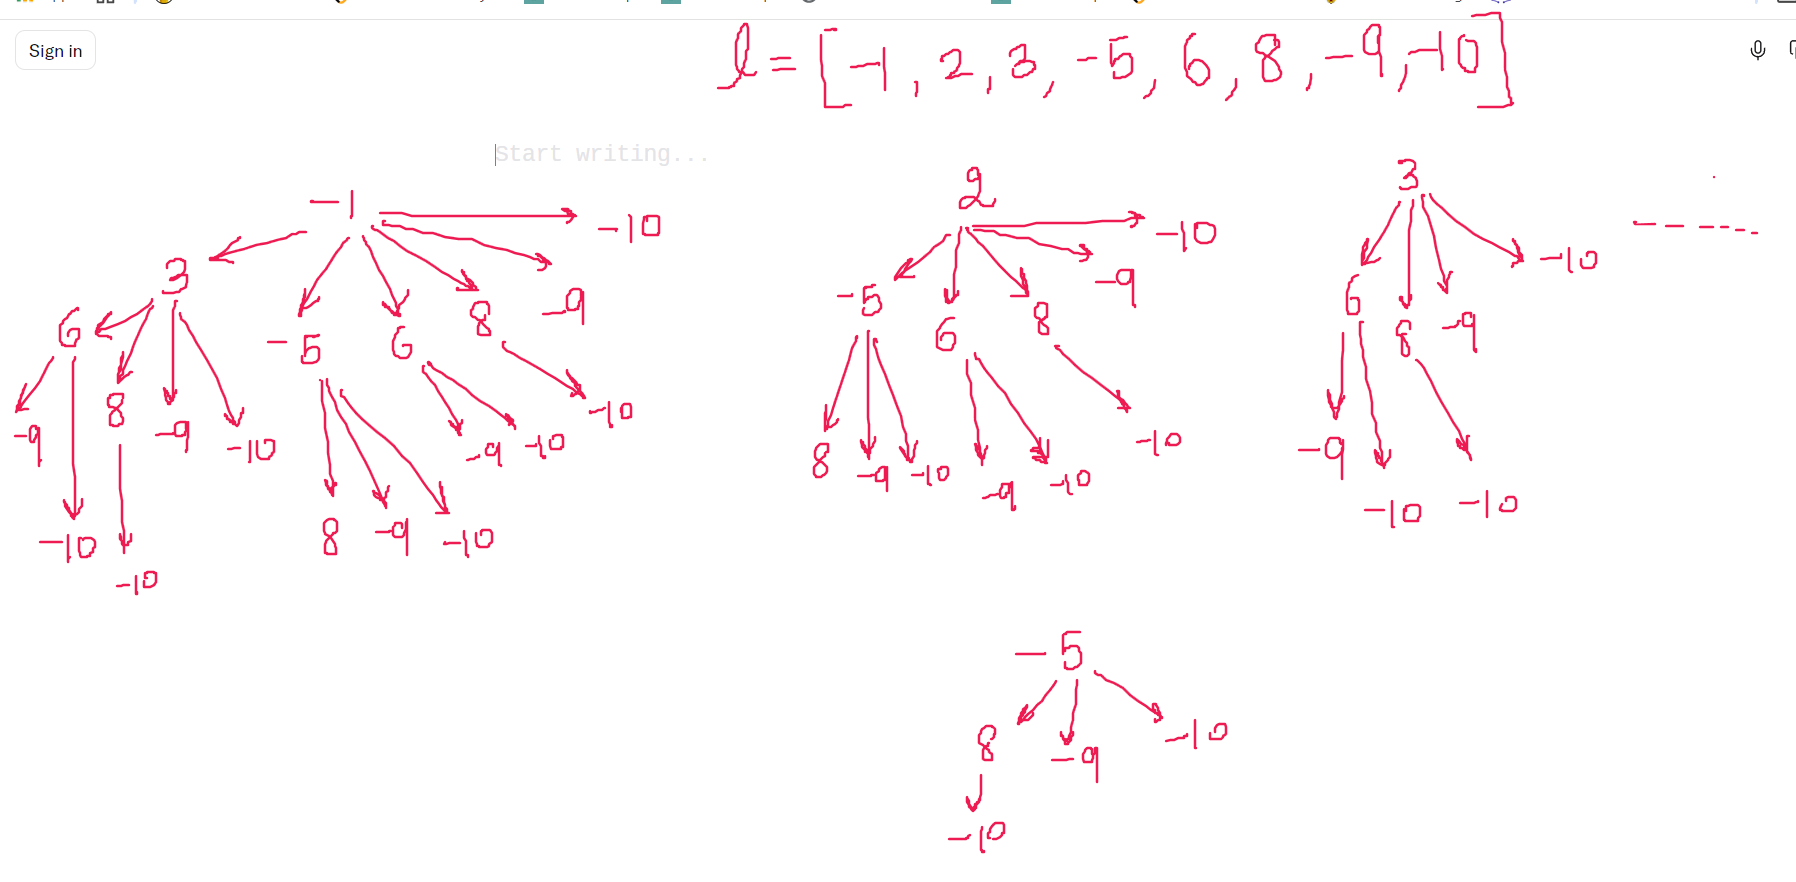

In [ ]:
def maxsum(l):
  n = len(l)
  if n==0:
    return 0
  if n==1:
    return l[0]

  best=l[0]

  def backtrack(start,current):
    nonlocal best
    # if start>=n:
    #   return
    best=max(best,current)
    for i in range(start+2,n):
      current+=l[i]
      best=max(best,current)
      backtrack(i,current)
      current-=l[i]


  for start in range(0,n):
    current=l[start]
    backtrack(start,current)

  return best

In [ ]:
maxsum([-2, 1, -3, 4, -1, 2, 1, -5, 4])

11

In [ ]:
def test_max_non_adjacent_sum():
    """
    Each test case is of the form:
    (input_array, expected_max_sum)
    """
    test_cases = [ # Single element (negative)
        ([-5], -5),
        # Two elements (both negative)
        ([-3, -7], -3),
        # All negative elements
        ([-2, -1, -3, -4], -1),
        # Mixed positive and negative
        ([3, 2, 5, 10, 7], 15),          # 3 + 5 + 7
        ([-2, 1, 3, -4, 5], 8),          # 3 + 5
        ([4, -1, 2, -1, 6], 12),         # 4 + 2 + 6
        # Zeros included
        ([0, 0, 0, 0], 0), ([0, -1, 0, -2, 0], 0),
        # Alternating negatives and positives
        ([5, -1, 5, -1, 5], 15), ([-1, 5, -1, 5, -1], 10),
        # Larger negatives between positives
        ([10, -100, 10, -100, 10], 30),
        # Edge-style tricky cases
        ([1, -2, 3, -2, 5], 9),          # 1 + 3 + 5
        ([-1, -2, -3, -4, -5], -1),
        # Classic interview cases
        ([2, 7, 9, 3, 1], 12),            # 2 + 9 + 1
        ([5, 5, 10, 100, 10, 5], 110),    # 5 + 100 + 5
    ]
    for arr, expected in test_cases:
        print(f"Array: {arr}")
        print(f"Expected Max Non-Adjacent Sum: {expected},  Obtained = {maxsum(arr) }, ")
        print("-" * 50)


# Run tests
test_max_non_adjacent_sum()


# **Q.25 22. Generate Parentheses**

Given n pairs of parentheses, write a function to generate all combinations of well-formed parentheses.



**Example 1:**

Input: $n = 3$
Output: $["((()))","(()())","(())()","()(())","()()()"]$


**Example 2:**

Input: $n = 1$
Output: $["()"]$


Constraints:

$1 <= n <= 8$

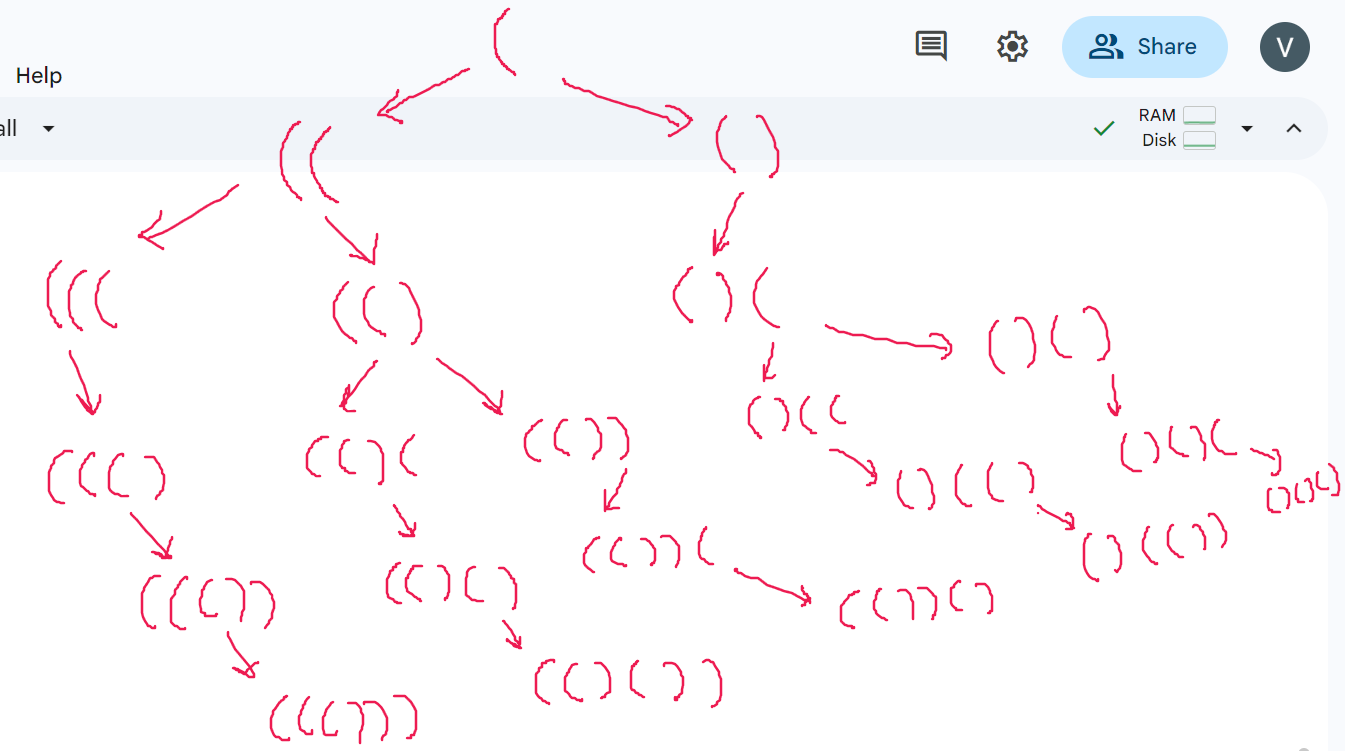

In [ ]:
def parentheses(n):
  if n==0:
    return []
  result=[]
  str=""

  def backtrack(nleft,nright):
    nonlocal str
    if nleft==n and nright==n:
      result.append(str)
      return
    if nleft<n:
      str+="("
      backtrack(nleft+1,nright)
      str=str[:-1]
    if nright<n and nright<nleft:
      str+=")"
      backtrack(nleft,nright+1)
      str=str[:-1]

  backtrack(0,0)
  return result

In [ ]:
parentheses(3)

['((()))', '(()())', '(())()', '()(())', '()()()']

# **Q. 26 53. Maximum Subarray**

Given an integer array nums, find the subarray with the largest sum, and return its sum.



Example 1:

Input: $nums = [-2,1,-3,4,-1,2,1,-5,4]$

Output: 6

Explanation: The subarray [4,-1,2,1] has the largest sum 6.


Example 2:

Input: $nums = [1]$

Output: 1

Explanation: The subarray [1] has the largest sum 1.

Example 3:

Input: $nums = [5,4,-1,7,8]$

Output: 23

Explanation: The subarray [5,4,-1,7,8] has the largest sum 23.


Constraints:

$1 <= nums.length <= 105$

$-104 <= nums[i] <= 104$

In [ ]:
"""
Let dp[i] = maximum sum of the subarray ending at the ith index

then dp[i+1] = max(dp[i], dp[i]+a[i+1])
"""

'\nLet dp[i] = maximum sum of the subarray ending at the ith index\n\nthen dp[i+1] = max(dp[i], dp[i]+a[i+1])\n'

In [ ]:
#class Solution:
def maxSubArray(nums):
  # Let dp[i] = maximum sum of the subarray ending at the ith index
  n = len(nums)
  dp = [0 for _ in range(n)]
  dp[0]=nums[0]
  best=0
  for i in range(1,n):
    dp[i] = max(dp[i-1]+nums[i] ,nums[i])
  return max(dp)

In [ ]:
maxSubArray([6,-5,-7,14,-1,7,8])

28

In [ ]:
maxSubArray([5,4,-1,7,8])

23

# **Q. 27 Word Search (Grid Backtracking)**

79. Word Search

Given an $m \times n$ grid of characters board and a string word, return true if word exists in the grid.

The word can be constructed from letters of sequentially adjacent cells, where adjacent cells are horizontally or vertically neighboring. The same letter cell may not be used more than once.



#Example 1:

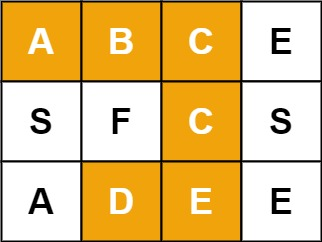


Input: board = [

  ["A","B","C","E"],
  
  ["S","F","C","S"],
  
  ["A","D","E","E"]],
  
  word = "ABCCED"


Output: true


#Example 2:

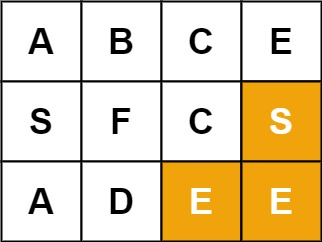


Input: board = [
  
  ["A","B","C","E"],
  
  ["S","F","C","S"],
  
  ["A","D","E","E"]],
  
  word = "SEE"


Output: true


#Example 3:

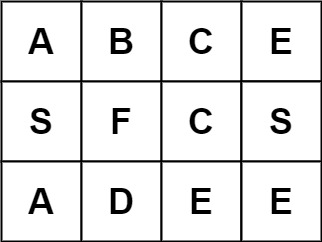


Input: board = [
  
  ["A","B","C","E"],
  
  ["S","F","C","S"],
  
  ["A","D","E","E"]],
  
  word = "ABCB"


Output: false


Constraints:

m == board.length

n = board[i].length

1 <= m, n <= 6

1 <= word.length <= 15

board and word consists of only lowercase and uppercase English letters.

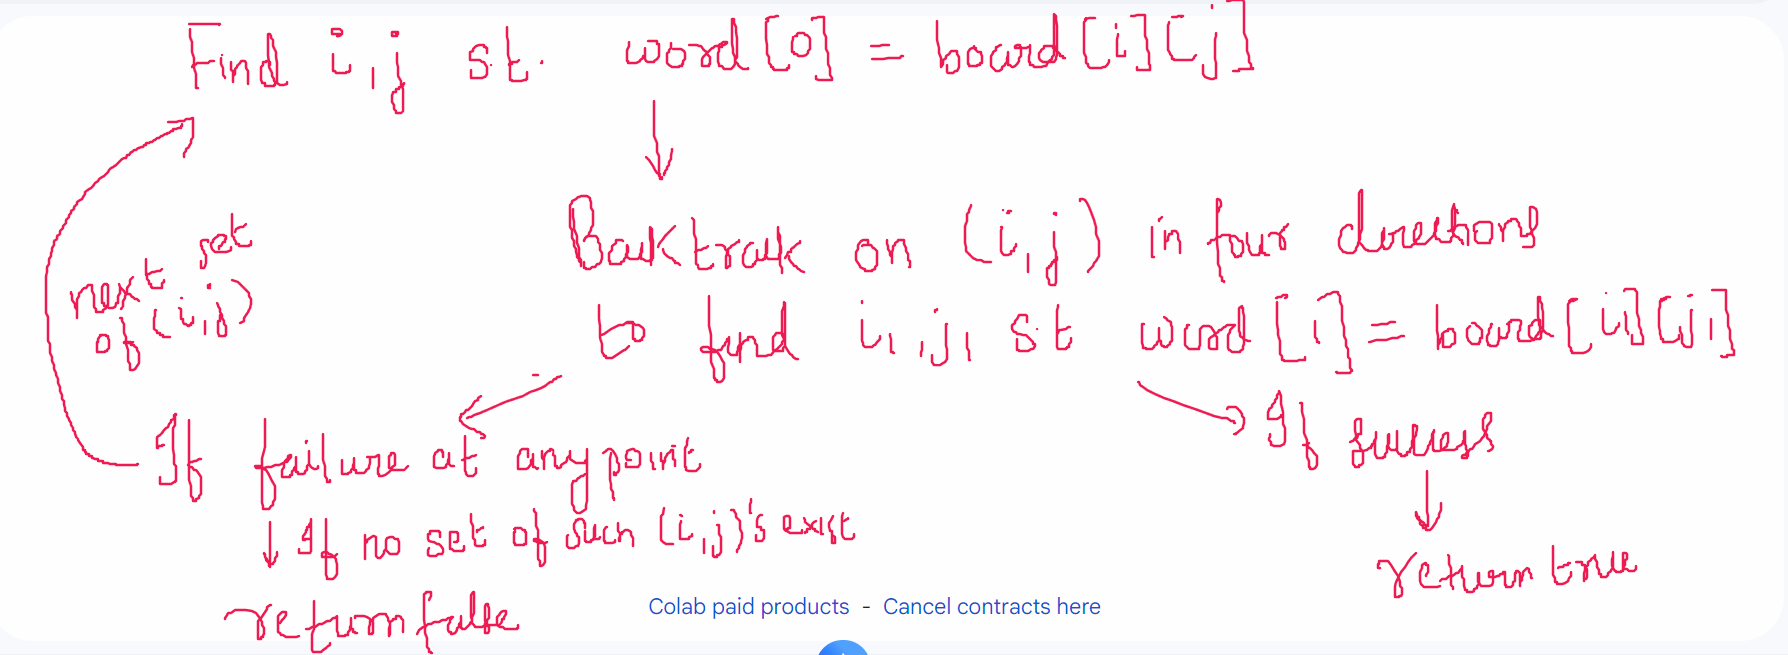

# **(A) Spot the error with this code**

In [ ]:
def exist(board, word):
  reject_list=[]
  n1=len(board)
  n2=len(board[0])
  word_length=len(word)

  def find_starting_indices():
    nonlocal board,word
    for row in range(len(board)):
      if word[0] not in board[row]:
        continue
      else:
        l = [col for col, val in enumerate(board[row]) if val == word[0]]

        for col in l:
          reject_list.append((row,col))
          if backtrack(row,col,1):
            return True
          reject_list.pop()

    return False

  def backtrack(row,col,word_index):
    nonlocal board,word,n1,n2

    if word_index==len(word):
      return True

    letter=word[word_index]

    if row+1<=n1-1 and board[row+1][col]==letter and (row+1,col) not in reject_list:
      reject_list.append((row+1,col))
      backtrack(row+1,col,word_index+1)
      reject_list.pop()

    if 0<=row-1 and board[row-1][col]==letter and (row-1,col) not in reject_list:
      reject_list.append((row-1,col))
      backtrack(row-1,col,word_index+1)
      reject_list.pop()

    if col+1<=n2-1 and board[row][col+1]==letter and (row,col+1) not in reject_list:
      reject_list.append((row,col+1))
      backtrack(row,col+1,word_index+1)
      reject_list.pop()

    if 0<=col-1 and board[row][col-1]==letter and (row,col-1) not in reject_list:
      reject_list.append((row,col-1))
      backtrack(row,col-1,word_index+1)
      reject_list.pop()

    return False

  return find_starting_indices()

In [ ]:
exist([["A","B","C","E"],["S","F","C","S"],["A","D","E","E"]], "ABCCED")


False

In [ ]:
"""
The logic that i used it is that even though i have these instructions:

 backtrack(row+1, col, word_index+1)

 I still have this code:

 if word_index==len(word):
     return True

The backtrack function if it is true must eventually reach the true statement

#####################

You are thinking: “Even if I just call

backtrack(row+1, col, word_index+1)

eventually the execution inside that function will hit return True, so the
algorithm should succeed.”

This belief is false, and the reason is subtle but exact. The critical
distinction you are missing is, There are two different questions:

Does a recursive call ever execute return True internally?
→ Yes, in your code, it does.

Does that True affect the caller’s control flow?
→ No, unless you explicitly use it.

Backtracking success is about control flow, not about “somewhere a True happened”.

What return True actually does (mechanically)

When Python executes:

return True


inside backtrack, it does only this:

Ends the current function call

Hands the value True to the immediate caller

Execution resumes after the function call line

Nothing else.

It does not:

Stop sibling branches

Stop parent frames

Automatically propagate upward

"""

# **(B)  Correct Code**

In [ ]:
def exist(board, word):
  reject_list=[]
  n1=len(board)
  n2=len(board[0])
  word_length=len(word)

  def find_starting_indices():
    nonlocal board,word
    for row in range(len(board)):
      if word[0] not in board[row]:
        continue
      else:
        l = [col for col, val in enumerate(board[row]) if val == word[0]]

        for col in l:
          reject_list.append((row,col))
          if backtrack(row,col,1):
            return True
          reject_list.pop()

    return False

  def backtrack(row,col,word_index):
    nonlocal board,word,n1,n2

    if word_index==len(word):
      return True

    letter=word[word_index]

    if row+1<=n1-1 and board[row+1][col]==letter and (row+1,col) not in reject_list:
      reject_list.append((row+1,col))
      if backtrack(row+1,col,word_index+1):
        return True
      reject_list.pop()

    if 0<=row-1 and board[row-1][col]==letter and (row-1,col) not in reject_list:
      reject_list.append((row-1,col))
      if backtrack(row-1,col,word_index+1):
        return True
      reject_list.pop()

    if col+1<=n2-1 and board[row][col+1]==letter and (row,col+1) not in reject_list:
      reject_list.append((row,col+1))
      if backtrack(row,col+1,word_index+1):
        return True
      reject_list.pop()

    if 0<=col-1 and board[row][col-1]==letter and (row,col-1) not in reject_list:
      reject_list.append((row,col-1))
      if backtrack(row,col-1,word_index+1):
        return True
      reject_list.pop()

    return False

  return find_starting_indices()

In [ ]:
exist([["A","B","C","E"],["S","F","C","S"],["A","D","E","E"]], "ABCCEDAF")


False

# **Q. 28 Problem: Path With Given Sum (Backtracking on Grid)**

You are given a 2D grid of integers and a target sum S.

Starting from any cell, you may move up, down, left, or right.
Each cell may be used at most once in a path.

Task

Write a function that returns True if there exists any path whose sum of values equals exactly S, otherwise return False.

grid = [

    [1, 3, 2],    
    [5, 4, 1],
    [1, 2, 1]
]

S = 10

Valid path (one possible):

1 → 3 → 4 → 2


Output:

True

In [ ]:
def exists(grid,number):
  n1 = len(grid)
  n2 = len(grid[0])
  reject_list=[]

  def backtrack(row,col,remaining):
    if remaining == 0:
      return True
    if remaining<0:
      return False

    if row+1<=n1-1 and (row+1,col) not in reject_list:
      reject_list.append((row+1,col))
      if backtrack(row+1,col,remaining-grid[row+1][col]):
        return True
      reject_list.pop()

    if 0<=row-1 and (row-1,col) not in reject_list:
      reject_list.append((row-1,col))
      if backtrack(row-1,col,remaining-grid[row-1][col]):
        return True
      reject_list.pop()

    if col+1<=n2-1 and (row,col+1) not in reject_list:
      reject_list.append((row,col+1))
      if backtrack(row,col+1,remaining-grid[row][col+1]):
        return True
      reject_list.pop()

    if 0<=col-1 and (row,col-1) not in reject_list:
      reject_list.append((row,col-1))
      if backtrack(row,col-1,remaining-grid[row][col-1]):
        return True
      reject_list.pop()

  for i in range(len(grid)):
    for j in range(len(grid[0])):
      reject_list.append((i,j))
      if backtrack(i,j,number-grid[i][j] ):
        print([grid[i][j] for(i,j) in reject_list])
        return True
      reject_list.pop()
  return False

In [ ]:
exists([ [1, 3, 2],
         [5, 4, 1],
         [1, 2, 1] ], 16)

[1, 5, 1, 2, 4, 3]


True

In [ ]:
def run_tests():
    test_cases = [
        # 1. Single cell equals target
        ( [[5]], 5, True  ),
        # 2. Single cell does not equal target
        ( [[5]], 3, False ),
        # 3. Simple straight path (right)
        ( [[1, 2, 3]], 6, True  ),
        # 4. Simple straight path (down)
        ( [[1], [2], [3]], 6, True ),
        # 5. Requires turning
        ( [ [1, 3, 2], [5, 4, 1] ],  8,  True  ),
        # 6. Full grid traversal path (CORRECTED)
        ( [ [1, 2],[3, 4] ],10, True ),
        # 7. All ones, must use multiple cells
        ( [ [1, 1],[1, 1] ], 3, True ),
        # 8. Negative values present
        ([[2, -1],[3, 1]], 4, True ),
        # 9. Requires branching search
        ([[1, 3, 2],[5, 4, 1],[1, 2, 1]],10,True),
        # 10. Impossible large target
        ( [[1, 2, 3],[4, 5, 6],[7, 8, 9] ],100,False )
    ]

    for i, (grid, target, expected) in enumerate(test_cases, 1):
        result = exists(grid, target)
        print(f"Test {i}: Target={target}")
        print(f"Expected: {expected}, Got: {result}")
        print("PASS" if result == expected else "FAIL")
        print("-" * 50)

run_tests()

In [ ]:
def run_additional_tests():
    test_cases = [
        # 11. Valid path starts at (0,1)
        ( [[9, 1, 2], [8, 3, 4] ], 10, True ),
        # 12. Valid path starts at (1,0)
        ( [ [5, 5], [2, 3] ], 5,True ),
        # 13. Valid path starts at center
        ( [ [9, 9, 9], [9, 4, 1], [9, 2, 3] ], 10, True ),
        # 14. Valid path starts at bottom-right corner
        ( [ [9, 9, 9], [9, 9, 1], [9, 2, 3] ], 6, True ),
        # 15. Path exists but (0,0) is a dead end
        ( [ [10, 1, 1], [1, 2, 3], [1, 1, 1] ], 6, True ),
        # 16. Negative values, start not at (0,0)
        ( [ [9, 9, 9], [9, -2, 5], [9, 3, 4] ], 10,True ),
        # 17. Only one cell matches target, not (0,0)
        ( [ [1, 1, 1], [1, 7, 1], [1, 1, 1] ], 7, True ),
        # 18. Multiple possible starts, only one valid
        ( [ [2, 2, 9], [2, 2, 2], [9, 2, 2] ], 6, True ),
        # 19. Large grid, valid path starts deep inside
        ( [ [9, 9, 9, 9], [9, 1, 2, 9], [9, 3, 4, 9], [9, 9, 9, 9] ], 10,True),
        # 20. No valid path anywhere (sanity check)
        ([ [1, 2, 3], [4, 5, 6], [7, 8, 9] ], 2, True ), ]

    for i, (grid, target, expected) in enumerate(test_cases, 11):
        result = exists(grid, target)
        print(f"Test {i}: Target={target}")
        print(f"Expected: {expected}, Got: {result}")
        print("PASS" if result == expected else "FAIL")
        print("-" * 50)


run_additional_tests()

# **Q. 29 85. Maximal Rectangle**

Given a rows x cols binary matrix filled with 0's and 1's, find the largest rectangle containing only 1's and return its area.



Example 1:

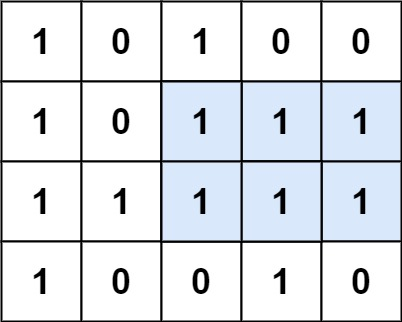

Input: matrix = [

  ["1","0","1","0","0"],

  ["1","0","1","1","1"],

  ["1","1","1","1","1"],

  ["1","0","0","1","0"]
  ]

Output: 6

Explanation: The maximal rectangle is shown in the above picture.


Example 2:

Input: matrix = [["0"]]

Output: 0

Example 3:

Input: matrix = [["1"]]

Output: 1


Constraints:

rows == matrix.length

cols == matrix[i].length

1 <= rows, cols <= 200

matrix[i][j] is '0' or '1'.

# **Q. 30 37. Sudoku Solver**

Write a program to solve a Sudoku puzzle by filling the empty cells.

A sudoku solution must satisfy all of the following rules:

Each of the digits 1-9 must occur exactly once in each row.

Each of the digits 1-9 must occur exactly once in each column.

Each of the digits 1-9 must occur exactly once in each of the 9 3x3 sub-boxes of the grid.

The '.' character indicates empty cells.

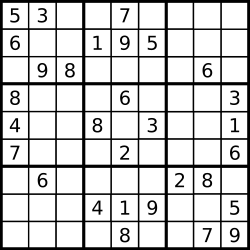

Input: board = [["5","3",".",".","7",".",".",".","."],["6",".",".","1","9","5",".",".","."],[".","9","8",".",".",".",".","6","."],["8",".",".",".","6",".",".",".","3"],["4",".",".","8",".","3",".",".","1"],["7",".",".",".","2",".",".",".","6"],[".","6",".",".",".",".","2","8","."],[".",".",".","4","1","9",".",".","5"],[".",".",".",".","8",".",".","7","9"]]

Output: [["5","3","4","6","7","8","9","1","2"],["6","7","2","1","9","5","3","4","8"],["1","9","8","3","4","2","5","6","7"],["8","5","9","7","6","1","4","2","3"],["4","2","6","8","5","3","7","9","1"],["7","1","3","9","2","4","8","5","6"],["9","6","1","5","3","7","2","8","4"],["2","8","7","4","1","9","6","3","5"],["3","4","5","2","8","6","1","7","9"]]

Explanation: The input board is shown above and the only valid solution is shown below:

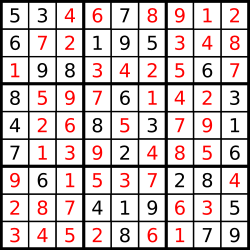

Constraints:

board.length == 9

board[i].length == 9

board[i][j] is a digit or '.'.

It is guaranteed that the input board has only one solution.



# **Q.31 64. Minimum Path Sum**

Given a $m \times n$ grid filled with non-negative numbers, find a path from top left to bottom right, which minimizes the sum of all numbers along its path.

Note: You can only move either down or right at any point in time.


Example 1:

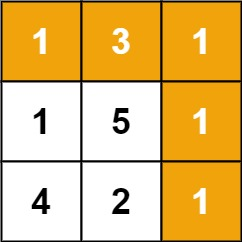

Input: grid = [[1,3,1],[1,5,1],[4,2,1]]

Output: 7

Explanation: Because the path 1 → 3 → 1 → 1 → 1 minimizes the sum.

Example 2:

Input: grid = [[1,2,3],[4,5,6]]

Output: 12


Constraints:

m == grid.length

n == grid[i].length

1 <= m, n <= 200

0 <= grid[i][j] <= 200


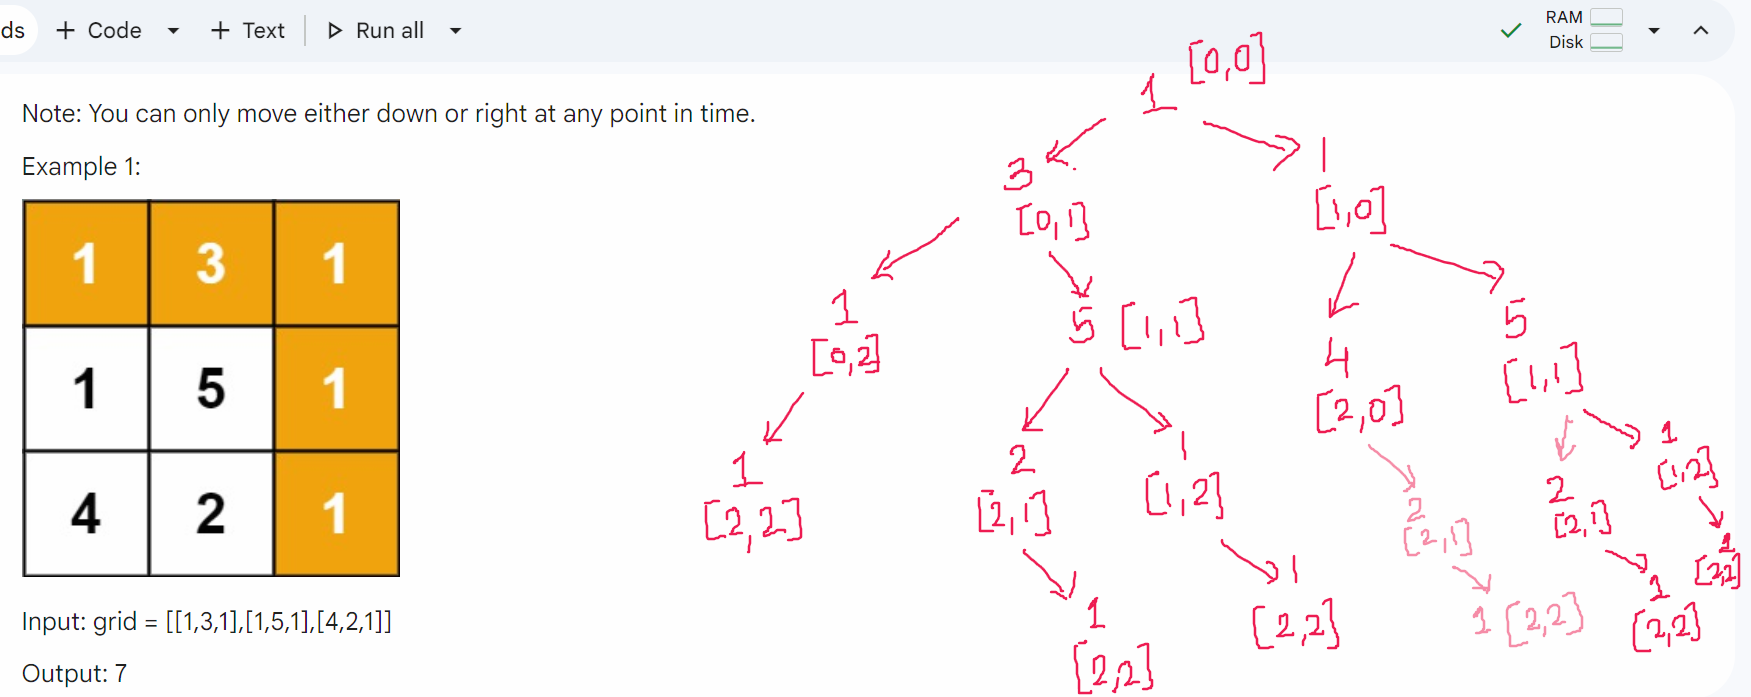

# **(a) Backtracking solution**

In [ ]:
def minPathSum(grid):
  n1=len(grid)
  n2=len(grid[0])
  total=grid[0][0]
  current=0
  best=float('inf')
  reject_list=[]

  def backtrack(row,col):
    nonlocal n1,n2,current,best

    current = current + grid[row][col]

    if current>=best:
      current = current - grid[row][col]
      return

    if row==n1-1 and col==n2-1:
      best = min(current,best)
      current = current - grid[row][col]
      return

    if row+1<=n1-1:
      backtrack(row+1,col)
    if col+1<=n2-1:
      backtrack(row,col+1)

    current = current - grid[row][col]

  backtrack(0,0)
  return best

In [ ]:
minPathSum([[1,2,3],[4,5,6]])

12

# **(b) Dynamic programming solution**

In [ ]:
def minPathSum(grid):
    n1, n2 = len(grid), len(grid[0])

    for i in range(n1):
        for j in range(n2):
            if i == 0 and j == 0:
                continue
            elif i == 0:
                grid[i][j] += grid[i][j-1]
            elif j == 0:
                grid[i][j] += grid[i-1][j]
            else:
                grid[i][j] += min(grid[i-1][j], grid[i][j-1])

    return grid[n1-1][n2-1]


In [ ]:
minPathSum([[1,3,1],[1,5,1],[4,2,1]])

7

# **Q. 32 Print all possible sum of elements in an array**

# **Effecient way**

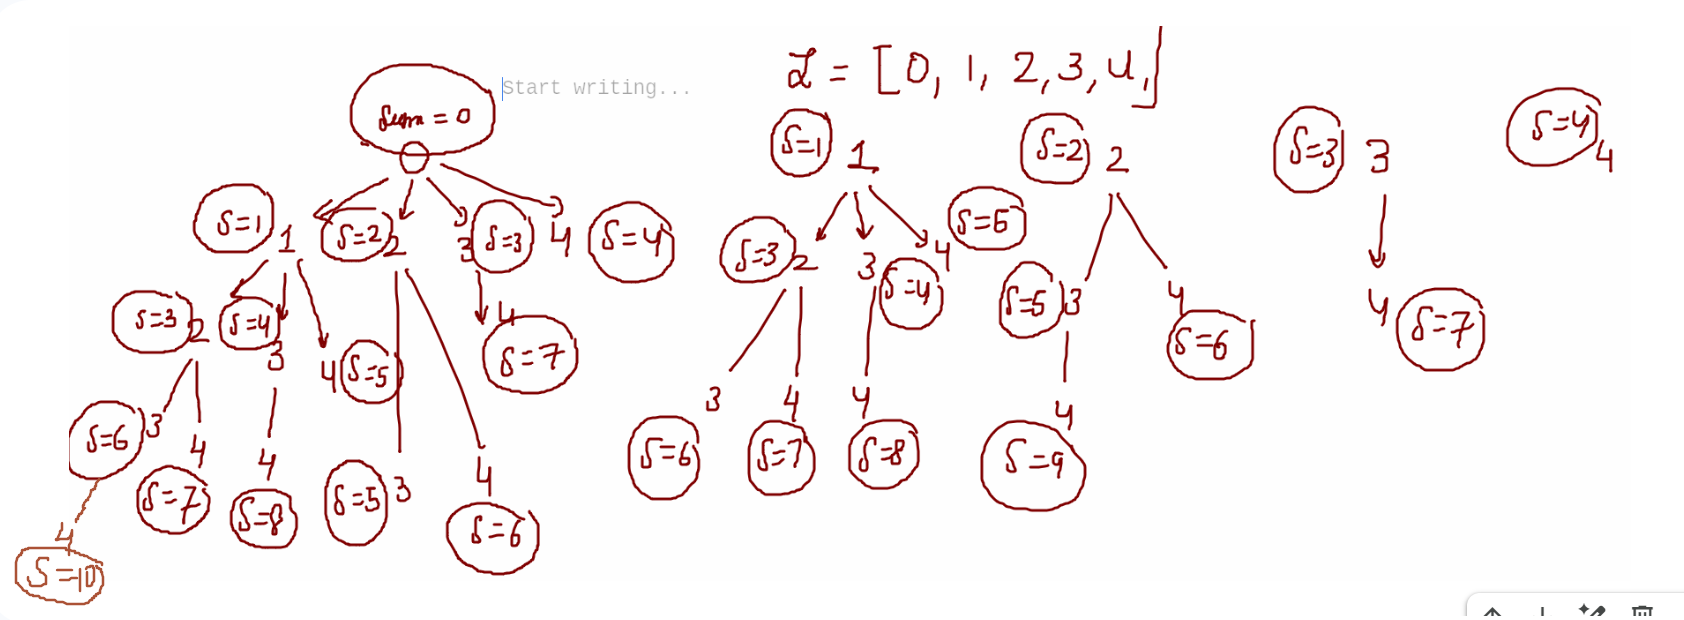

at any given point, you have two choices to make to simulate that loop:

"Horizontal" move: Skip the current element and try the next one at the same level (this replaces the next iteration of the loop).

"Vertical" move: Include the current element and move down to the next level.

In [ ]:
def allSums(l):
    n = len(l)
    result = [0] # Starting with the root S=0

    def backtrack(index, summ):
        # Base case: stop when we run out of elements
        if index == n:
            return

        # 1. Vertical Move: Include the current element
        new_sum = summ + l[index]
        if new_sum not in result:
          result.append(new_sum)
        backtrack(index + 1, new_sum)

        # 2. Horizontal Move: Skip the current element
        backtrack(index + 1, summ)

    backtrack(0, 0)
    return result

L = [0, 1, 2, 3, ]
print(allSums(L))

[0, 1, 3, 6, 4, 2, 5]


In [ ]:
allSums([1,2,3])

# **Ineffecient way**
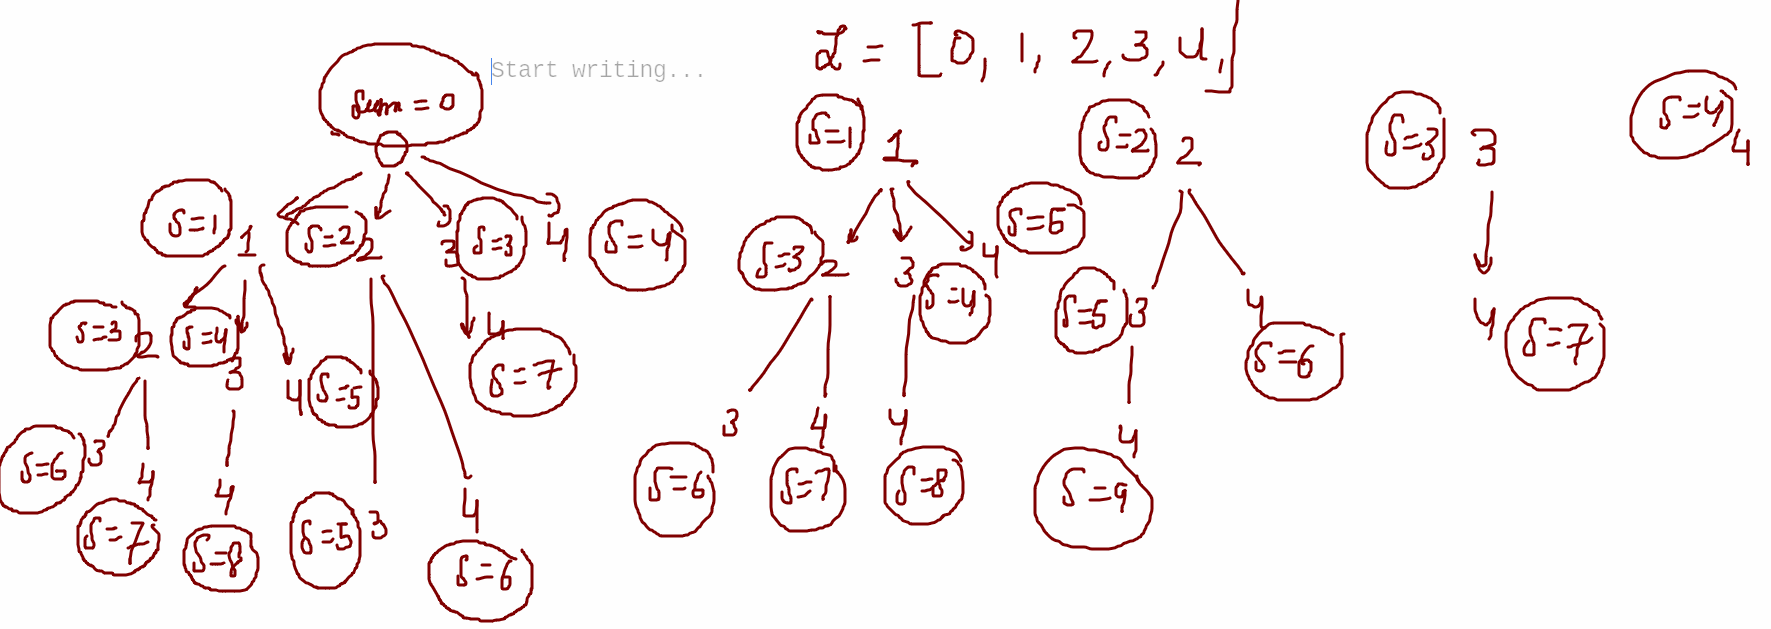

In [ ]:
def allSums(l):
  n = len(l)
  if n == 0:
    return [0]

  result = []
  summ = 0
  result.append(summ)

  def backtrack(i):
    nonlocal summ, n

    if i == n:
      return

    summ += l[i]

    if summ not in result:
      result.append(summ)

    for j in range(i+1, n):
      backtrack(j)

    summ -= l[i]

  for i in range(n):
    summ = 0
    backtrack(i)

  return result


# **Effecient way**

In [ ]:
"""
                         0
                   /            \
               +1                 0
            /        \         /        \
        +2             1     +2           0
      /   \          /  \   /   \        /   \
   +3     2       +3     1 +3     2     +3     0

"""

In [ ]:
def allSums(l):
    n = len(l)
    sums = set()
    curr = 0

    def backtrack(i):
        nonlocal curr

        if i == n:
            sums.add(curr)
            return

        # include
        curr += l[i]
        backtrack(i + 1)

        # undo
        curr -= l[i]

        # exclude
        backtrack(i + 1)

    backtrack(0)
    return list(sums)


In [ ]:
allSums([1,2,3])

UnboundLocalError: cannot access local variable 'sum' where it is not associated with a value

#Q. 33 **93. Restore IP Addresses**

A valid IP address consists of exactly four integers separated by single dots. Each integer is between 0 and 255 (inclusive) and cannot have leading zeros.

For example, $"0.1.2.201"$ and $"192.168.1.1"$ are valid IP addresses, but $"0.011.255.245"$, $"192.168.1.312"$ and $"192.168@1.1"$ are invalid IP addresses.

Given a string s containing only digits, return all possible valid IP addresses that can be formed by inserting dots into s. You are not allowed to reorder or remove any digits in s. You may return the valid IP addresses in any order.



**Example 1:**

Input: s = $"25525511135"$

Output: $["255.255.11.135","255.255.111.35"]$

**Example 2:**

Input: s = $"0000"$

Output: $["0.0.0.0"]$

**Example 3:**

Input: s = $"101023"$

Output: $["1.0.10.23","1.0.102.3","10.1.0.23","10.10.2.3","101.0.2.3"]$

If you were writing code to check if a path is valid (like in your tree), the branch must pass these three tests:Quantity: There must be exactly 4 segments.Range: Each segment must be $\ge 0$ and $\le 255$.

Formatting: No "leading zeros." (e.g., 192.168.01.1 is invalid because of the 01).


**Constraints:**

1 <= s.length <= 20

s consists of digits only.

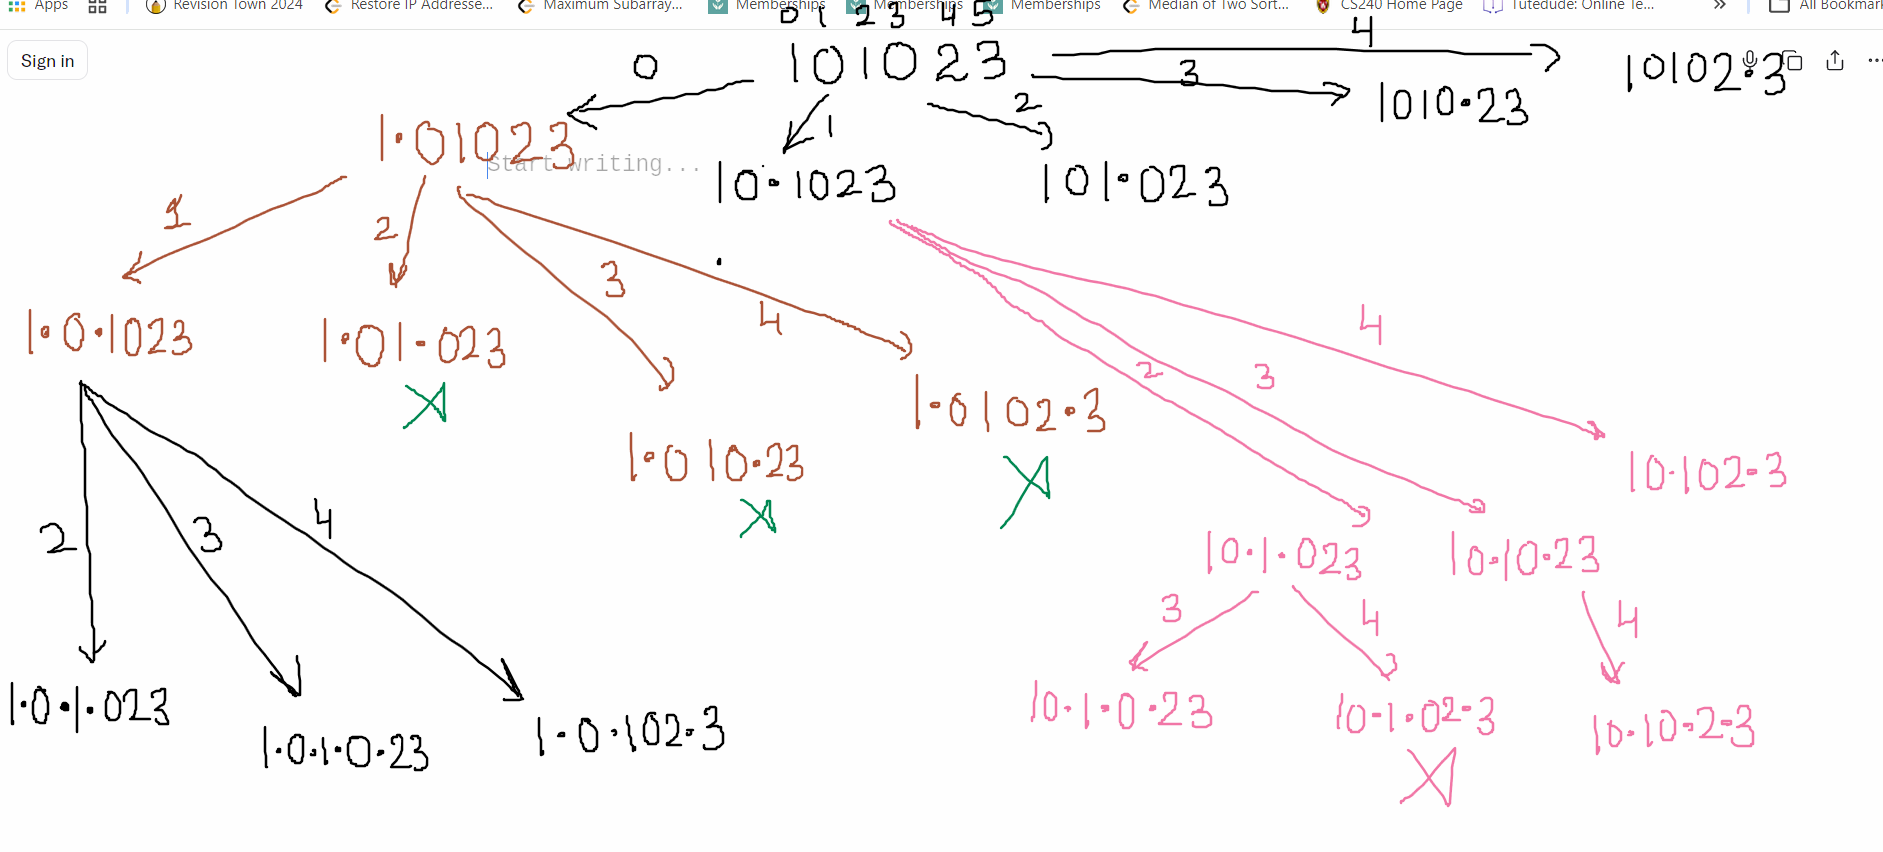

In [ ]:
def restoreIpAddresses(s):
    result=[]
    n = len(s)
    if n<4 or n>12:
        return result
    dot_places=[]

    def add_dots(s,counter,dot_places):
      if counter==len(dot_places):
        return s
      pos = counter+dot_places[counter]+1
      s=s[:pos]+"." + s[pos:]
      return add_dots(s,counter+1,dot_places)

    def backtrack(index,counter):
        nonlocal dot_places

        if counter==3 and 0<=int(s[dot_places[-1]+1:])<=255\
        and len(s[dot_places[-1]+1:])<=3 and\
        not (s[dot_places[-1]+1]=='0' and len(s[dot_places[-1]+1:])>=2):

            s1 = add_dots(s,0,dot_places)
            result.append(s1)
            return
        # No. of parts = counter + 1    and uncovered length = n-index
        # remaining no. of dots = 3 - counter
        # => remaining parts = 3 - counter + 1 = 4 - counter
        # => If n - index > 3*(4 - counter), return ""

        if index>=n-1 or n-index>3*(4-counter):
          return

        if dot_places:
          val = s[dot_places[-1]+1:index+1]
          len1 = len(val)
        else:
          val = s[:index+1]
          len1 = len(val)

        if 0<=int(val)<=255 and len1<=3 and\
        not (val[0]=='0' and len1>=2):

          dot_places.append(index)
          backtrack(index+1,counter+1)
          dot_places.pop()

        backtrack(index+1,counter)
    backtrack(0,0)
    return result
print(restoreIpAddresses("25525511135"))
print(restoreIpAddresses("010010"))
print(restoreIpAddresses("0000"))
print(restoreIpAddresses("127001"))
restoreIpAddresses("11011")
restoreIpAddresses("1101111123123")
#['1.1.0.11', '1.10.1.1', '11.0.1.1']

['255.255.11.135', '255.255.111.35']
['0.10.0.10', '0.100.1.0']
['0.0.0.0']
['12.70.0.1', '127.0.0.1']


[]

In [ ]:
test_cases = [
    ("25525511135", 2),  # Standard long case
    ("0000", 1),         # Minimum valid
    ("1111", 1),         # Simple case
    ("010010", 2),       # Leading zeros within segments
    ("101023", 5),       # Multiple combinations
    ("255255255255", 1), # Maximum valid
    ("19216811", 9),     # Common local IP format
    ("", 0),             # Empty string
    ("111", 0),          # Too short
    ("1111111111111", 0),# Too long (>12 chars)
    ("00000", 0),        # Too many zeros
    ("300300300300", 0), # All segments out of range
    ("172162541", 6),    # Medium length
    ("12345", 4),        # Short but multiple ways
    ("01001", 1),        # Tricky zeros: "0.10.0.1"
    ("10000", 1),        # "10.0.0.0"
    ("256256256256", 0), # Just over the limit
    ("99999999", 1),     # "99.99.99.99"
    ("11011", 3),        # "1.10.1.1", "1.1.0.1.1" etc (Wait, IP only has 4 parts)
    ("127001", 2),       # Localhost variants
]

print(f"{'Input String':<15} | {'Expected Count':<15} | {'Actual Count':<15} | {'Status'}")
print("-" * 65)

for s, expected_count in test_cases:
    actual = restoreIpAddresses(s)
    status = "✅ PASS" if len(actual) == expected_count else "❌ FAIL"
    print(f"{s:<15} | {expected_count:<15} | {len(actual):<15} | {status}")

Input String    | Expected Count  | Actual Count    | Status
-----------------------------------------------------------------
25525511135     | 2               | 2               | ✅ PASS
0000            | 1               | 1               | ✅ PASS
1111            | 1               | 1               | ✅ PASS
010010          | 2               | 2               | ✅ PASS
101023          | 5               | 5               | ✅ PASS
255255255255    | 1               | 1               | ✅ PASS
19216811        | 9               | 9               | ✅ PASS
                | 0               | 0               | ✅ PASS
111             | 0               | 0               | ✅ PASS
1111111111111   | 0               | 0               | ✅ PASS
00000           | 0               | 0               | ✅ PASS
300300300300    | 0               | 0               | ✅ PASS
172162541       | 6               | 6               | ✅ PASS
12345           | 4               | 4               | ✅ PASS
01001           | 1

In [ ]:
def restoreIpAddresses(s: str):
    result = []
    n = len(s)

    def backtrack(start, parts, path):

        if parts == 4:
            if start == n:
                result.append(".".join(path))
            return

        if start >= n:
            return

        for length in range(1,4):

            if start + length > n:
                break

            part = s[start:start+length]

            # no leading zero
            if part[0] == '0' and len(part) > 1:
                continue

            if int(part) > 255:
                continue

            backtrack(
                start + length,
                parts + 1,
                path + [part]
            )

    backtrack(0,0,[])
    return result


In [ ]:
restoreIpAddresses("127001")
restoreIpAddresses("11011")


['1.1.0.11', '1.10.1.1', '11.0.1.1']

Q. 34 Given an array arr[] where each element represents the max number of
steps that can be made forward from that index. The task is to find
the minimum number of jumps to reach the end of the array starting
from index 0.